<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.991 · Aprenentatge automàtic · PAC4</p>
<p style="margin: 0; text-align:right;">2025-1 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'informàtica, multimèdia i telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>



# **PAC 4: Combinació de Models**

## Objectiu
Aquesta quarta Prova d'Avaluació Continuada (PAC 4) té com a objectiu principal consolidar els coneixements adquirits en les PACs anteriors (introducció a l'aprenentatge automàtic, anàlisi exploratòria de dades, mètodes supervisats i no supervisats) i introduir i aprofundir en tècniques avançades d'Ensemble Learning (Aprenentatge per Conjunts).

En finalitzar aquesta PAC, hauries de ser capaç de:

* Implementar i comparar diverses tècniques d'ensemble learning (p. ex., Bagging/Random Forest, Boosting -AdaBoost, Gradient Boosting-, Stacking i cascading) sobre un conjunt de dades específic.
* Analitzar i explicar com els hiperparàmetres clau dels mètodes ensemble influeixen en el seu comportament i rendiment.
* Avaluar i comparar la importància de les característiques (feature importance) obtinguda a través de diferents models ensemble.
* Justificar quan i per què un mètode ensemble podria ser preferible a un altre, o a un model individual (connectant amb conceptes com el trade-off biaix-variància).
* Aplicar correctament metodologies de validació (com validació creuada) per a l'avaluació i comparació robusta dels models ensemble.

## Conjunt de dades
Una companyia opera un parc eòlic crític amb 3000 turbines i busca optimitzar els seus costos operatius i assegurar la continuïtat del servei.

Actualment, l'estratègia de manteniment és ineficient: o bé és reactiva (arreglar quan es trenca, la qual cosa és molt costosa) o preventivo-fixa (revisar cada X mesos, la qual cosa malbarata recursos en màquines sanes). El vostre objectiu és desenvolupar un model de Manteniment Predictiu basat en les dades dels sensors instal·lats a les turbines.

El dataset (`wind_turbine_data.csv`) conté lectures de sensors de vibració, temperatura, elèctrics i ambientals. Els valors dels sensors ja han estat transformats per l'equip d'enginyeria de dades. Es presenten com a **z-scores (estandarditzats)**. Això significa que veureu valors positius i negatius centrats en zero. Un valor de `0` indica que el sensor està en la seva mitjana històrica operativa; valors alts (positius o negatius) indiquen desviacions anòmales respecte al comportament normal. Per exemple, una temperatura "negativa" no significa sota zero absolut, sinó que és més baixa que la mitjana habitual de funcionament.

Les variables del dataset s'agrupen per subsistemes de la turbina:

| Subsistema | Variables (Sensors) | Descripció |
| :--- | :--- | :--- |
| **Target** | `Operational_Status` | Variable a predir:<br>**0: Normal** (Funcionament òptim).<br>**1: Warning** (Alerta de Manteniment. Requereix visita).<br>**2: Failure** (Fallada Crítica. Aturada immediata necessària). |
| **Generador** | `Gen_Avg_RPM`<br>`Gen_Output_Voltage`<br>`Gen_Coil_Temp` | Revolucions per minut, voltatge de sortida i temperatura del bobinatge. |
| **Xarxa Elèctrica** | `Grid_Frequency_Hz` | Freqüència de sincronització amb la xarxa elèctrica. |
| **Rotor i Pales** | `Rotor_Blade_Angle_1`<br>`Rotor_Blade_Angle_2`<br>`Rotor_Shaft_Vibration`<br>`Rotor_Wind_Speed` | Angles de les pales, vibració de l'eix principal i velocitat del vent incident.<br>|
| **Hidràulica** | `Hydraulic_Oil_Pressure`<br>`Hydraulic_Oil_Temp`<br>`Hydraulic_Tank_Level` | Estat del sistema hidràulic (frens i orientació). |
| **Caixa de Canvis** | `Gearbox_Bearing_Temp`<br>`Gearbox_Vibration_X`<br>`Gearbox_Vibration_Y` | Temperatura de rodaments i vibració en eixos X/Y. |
| **Ambiental** | `Amb_Ext_Temp`<br>`Amb_Humidity`<br>`Amb_Wind_Turbulence`<br>`Tower_Oscillation` | Condicions externes i oscil·lació de la torre. |
| **Metadades** | `Installation_Region`<br>`Turbine_Model` | Regió geogràfica i model de la màquina. |

L'objectiu no és només implementar els algoritmes, sinó sobretot analitzar en profunditat el seu comportament, comparar els seus resultats i justificar les teves conclusions basant-te sempre en l'evidència obtinguda dels teus propis experiments i resultats numèrics/gràfics. Es valorarà especialment la capacitat crítica i la profunditat de les teves interpretacions.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<strong>Nom i cognom: Jordi Baiges Ferré</strong>
</div>

## 1. Càrrega, Anàlisi Exploratòria Crítica i Neteja de Dades (1 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Carrega el dataset <code>wind_turbine_data.csv</code>.
2. Anàlisi Exploratòria de Dades (EDA) Assistida per I.A.:
    - Utilitza una eina d'I.A. Generativa (p. ex. ChatGPT, Gemini, Copilot, Claude, etc.) per assistir-te en la realització d'una EDA exhaustiva.
    - Revisa la informació general del dataset (tipus de dades, variables categòriques/numèriques).
    - Analitza els valors atípics, els patrons de correlació i la distribució de la variable objectiu (`Operational_Status`).
3. **Anàlisi Crítica:** Basant-te únicament en les troballes de la teva EDA, discuteix els principals desafiaments que anticipes que aquest dataset podria presentar per als models de classificació estàndard. Identifica les variables més importants per a la classificació.
4. Preparació i Justificació de Dades:
    - Realitza les transformacions de dades necessàries per a la Classificació.
    - Justifica les teves decisions sobre: Codificació de variables categòriques, Escalament/Normalització de variables numèriques, i gestió de variables amb patrons de distribució no lineals (si decideixes transformar-les).
    - Recorda aplicar la divisió correcta entre conjunts Train/Test i evitar la fuga de dades. Usa sempre com a llavor el número 42.
5. **Anàlisi Crítica: Reflexió sobre l'Ús d'I.A. Generativa**
    - Sigues clar i honest: Quina eina d'I.A. has utilitzat i per a quines tasques específiques?
    - Identifica els suggeriments erronis o enganyosos que l'I.A. t'hagi donat durant l'EDA o la preparació de dades. Com els has corregit?
    - Conclou: Quin és el principal risc de delegar l'anàlisi completament a una I.A.?
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
IMPORTEM LLIBRERIES
</i></b></span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


<span style="color: purple;"><b><i>
Carrega el dataset wind_turbine_data.csv.
</i></b></span>


In [2]:
# --- PAS 1: Carregar el dataset wind_turbine_data.csv ---
import pandas as pd
from pathlib import Path

# Nosaltres indiquem la ruta del fitxer.
# Si el tens al mateix directori del notebook, això ja funciona tal qual.
# Si el tens en una altra carpeta, adapta la ruta (p. ex. Path("data/wind_turbine_data.csv")).
DATA_PATH = Path("wind_turbine_data.csv")

# Nosaltres llegim el CSV
df = pd.read_csv(DATA_PATH)

# Nosaltres comprovem dimensions i columnes
print("Dimensions (files, columnes):", df.shape)
print("\nColumnes:")
print(list(df.columns))

# Nosaltres revisem tipus de dades i valors nuls
print("\nInfo del dataset:")
df.info()

# Nosaltres mostrem les primeres files
display(df.head(10))


Dimensions (files, columnes): (3000, 24)

Columnes:
['Installation_Region', 'Turbine_Model', 'Gen_Avg_RPM', 'Gen_Output_Voltage', 'Gen_Coil_Temp', 'Grid_Frequency_Hz', 'Rotor_Blade_Angle_1', 'Rotor_Blade_Angle_2', 'Rotor_Wind_Speed', 'Rotor_Shaft_Vibration', 'Rotor_Shaft_Vibration_Redundant', 'Hydraulic_Oil_Pressure', 'Hydraulic_Oil_Temp', 'Hydraulic_Tank_Level', 'Gearbox_Bearing_Temp', 'Gearbox_Vibration_X', 'Gearbox_Vibration_Y', 'Amb_Ext_Temp', 'Amb_Humidity', 'Amb_Wind_Turbulence', 'Tower_Oscillation', 'Tower_Fatigue_Index', 'System_Efficiency_Calc', 'Operational_Status']

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Installation_Region              3000 non-null   object 
 1   Turbine_Model                    3000 non-null   object 
 2   Gen_Avg_RPM                      3000 

,Installation_Region,Turbine_Model,Gen_Avg_RPM,Gen_Output_Voltage,Gen_Coil_Temp,Grid_Frequency_Hz,Rotor_Blade_Angle_1,Rotor_Blade_Angle_2,Rotor_Wind_Speed,Rotor_Shaft_Vibration,...,Gearbox_Bearing_Temp,Gearbox_Vibration_X,Gearbox_Vibration_Y,Amb_Ext_Temp,Amb_Humidity,Amb_Wind_Turbulence,Tower_Oscillation,Tower_Fatigue_Index,System_Efficiency_Calc,Operational_Status
0,South_Plains,Turbine_Model_C,1.821258,0.910395,0.459186,-1.030711,2.098087,1.921148,-1.737789,-2.657309,...,1.897052,-1.394981,4.431102,0.699121,-1.445639,2.348258,0.652387,-0.374180,0.361828,2
1,South_Plains,Turbine_Model_B,4.229767,-0.434469,4.726087,0.995552,-3.966756,2.444360,0.848826,-3.308983,...,-5.080912,-1.526828,0.863514,0.032210,-0.047262,0.193590,1.075823,0.181950,3.457472,2
2,High_Mountains,Turbine_Model_D,0.860488,0.984565,0.042947,-0.365520,-4.947303,-0.574780,2.228463,-2.312484,...,-5.960220,-2.220760,-3.323280,-1.348569,0.282364,3.002487,0.343067,-0.461241,-0.046276,1
3,South_Plains,Turbine_Model_D,1.503285,1.769841,1.307190,1.309311,1.169251,0.514564,0.674670,0.847147,...,-1.040373,-1.001201,3.293377,0.117673,1.102933,1.347602,-0.644789,1.442618,1.055786,1
4,High_Mountains,Turbine_Model_B,-0.019055,-1.569077,-0.824806,2.347602,-1.001121,0.323452,-1.544061,-1.198919,...,3.031140,0.584622,4.140137,-0.174062,0.230008,1.357896,1.410082,-0.555238,0.688510,0
5,South_Plains,Turbine_Model_C,2.419295,-1.216189,0.655121,-0.585337,-1.683440,-0.373523,-2.695506,-0.855077,...,-1.181882,-0.101940,1.317702,7.709564,-0.212358,0.161524,0.374665,-0.607767,-0.650891,0
6,Interior_Valley,Turbine_Model_C,-1.461892,-0.656316,-1.508504,-1.186119,-3.720683,-0.806854,1.269319,0.673863,...,-1.603676,-0.025475,-3.359116,-0.426412,1.407049,1.328894,-0.221884,-2.518374,-0.790578,1
7,South_Plains,Turbine_Model_C,2.049725,-0.502627,2.895957,0.844321,0.069702,-0.286405,0.653946,-1.979587,...,-2.204383,0.901708,3.605577,1.873582,0.343831,1.973720,-0.643324,0.563309,0.105334,0
8,North_Coast,Turbine_Model_B,-1.862133,-0.260488,-3.413633,1.852591,2.493374,0.520710,1.465831,0.095968,...,4.596269,0.347196,1.733018,-5.354597,0.440646,0.478656,-0.233391,0.228926,-2.064520,0
9,South_Plains,Turbine_Model_C,1.596108,0.408852,2.378878,1.032226,1.526720,2.491424,-0.974922,1.563954,...,-0.366277,1.576300,2.663646,0.120504,0.427893,2.015048,-1.745661,-0.898496,2.319482,0


<span style="color: purple;"><b><i>
2. Anàlisi Exploratòria de Dades (EDA) Assistida per I.A.:<br>
• Utilitza una eina d’I.A. Generativa (p. ex. ChatGPT, Gemini, Copilot, Claude, etc.) per assistir-te en la realització d’una EDA exhaustiva.<br>
• Revisa la informació general del dataset (tipus de dades, variables categòriques/numèriques).<br>
• Analitza els valors atípics, els patrons de correlació i la distribució de la variable objectiu (Operational_Status).<br>
</i></b></span>


In [3]:
# Separem variables categòriques i numèriques, i identifiquem el target
TARGET = "Operational_Status"

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove(TARGET)

print("Categòriques:", cat_cols)
print("Numèriques:", len(num_cols))
print("Target:", TARGET)

# Punts clau que busquem aquí:

#* Confirmar que Operational_Status és el target (0=Normal, 1=Warning, 2=Failure), i que la resta són sensors/metadades. 

#* Separar bé cat/num perquè això condicionarà preprocessament i models.


Categòriques: ['Installation_Region', 'Turbine_Model']
Numèriques: 21
Target: Operational_Status


<span style="color: purple;"><b><i>
Qualitat de dades: nuls, duplicats i valors “estranys”<br>
</i></b></span>


In [4]:
# Nosaltres comprovem valors nuls i duplicats
missing = df.isna().mean().sort_values(ascending=False)
print("Top % nuls per columna:")
display((missing * 100).head(10))

print("Files duplicades:", df.duplicated().sum())

# Mirem estadístiques bàsiques numèriques per detectar rangs sospitosos
display(df[num_cols + [TARGET]].describe().T)



Top % nuls per columna:


Installation_Region      0.0
Turbine_Model            0.0
Gen_Avg_RPM              0.0
Gen_Output_Voltage       0.0
Gen_Coil_Temp            0.0
Grid_Frequency_Hz        0.0
Rotor_Blade_Angle_1      0.0
Rotor_Blade_Angle_2      0.0
Rotor_Wind_Speed         0.0
Rotor_Shaft_Vibration    0.0
dtype: float64

Files duplicades: 0


,count,mean,std,min,25%,50%,75%,max
Gen_Avg_RPM,3000.0,-0.167780,1.992783,-7.430478,-1.537541,-0.233910,1.121515,8.853569
Gen_Output_Voltage,3000.0,0.194072,2.009702,-7.017886,-1.085016,0.260095,1.573280,7.291045
Gen_Coil_Temp,3000.0,0.021713,1.988687,-6.903463,-1.288022,0.042402,1.419595,6.099481
Grid_Frequency_Hz,3000.0,0.565079,1.997788,-7.177407,-0.698250,0.616664,1.849444,7.803933
Rotor_Blade_Angle_1,3000.0,0.339354,1.988697,-7.157275,-1.032249,0.317372,1.672007,8.439868
Rotor_Blade_Angle_2,3000.0,0.001514,1.005382,-3.596199,-0.668274,-0.006355,0.653912,4.199419
Rotor_Wind_Speed,3000.0,0.200799,1.856595,-7.127550,-1.020612,0.237213,1.463993,6.515078
Rotor_Shaft_Vibration,3000.0,0.214931,1.905222,-6.640535,-1.106546,0.130390,1.446997,6.973083
Rotor_Shaft_Vibration_Redundant,3000.0,0.214931,1.905222,-6.640535,-1.106546,0.130390,1.446997,6.973083
Hydraulic_Oil_Pressure,3000.0,-0.574093,1.850820,-7.571720,-1.809644,-0.666510,0.517805,7.543879


<span style="color: purple;"><b><i>
Distribució del target (desbalanceig de classes)<br>
</i></b></span>


,count,prop
Operational_Status,,
0,1490,0.496667
1,907,0.302333
2,603,0.201000


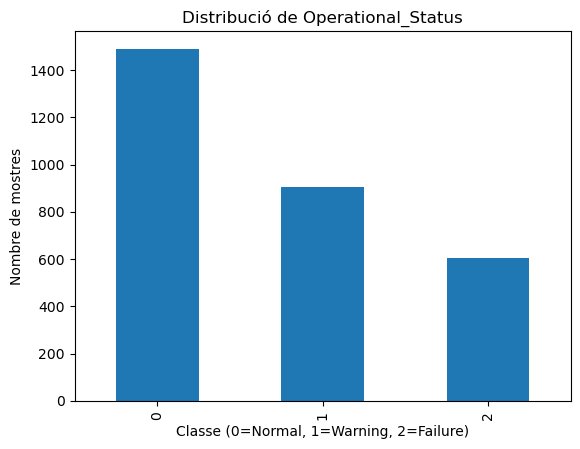

In [5]:
# Mesurem el recompte i el percentatge de cada classe
counts = df[TARGET].value_counts().sort_index()
props = df[TARGET].value_counts(normalize=True).sort_index()

display(pd.DataFrame({"count": counts, "prop": props}))

# Nosaltres ho visualitzem
ax = counts.plot(kind="bar")
ax.set_title("Distribució de Operational_Status")
ax.set_xlabel("Classe (0=Normal, 1=Warning, 2=Failure)")
ax.set_ylabel("Nombre de mostres")
plt.show()

# Com ho interpretem i per què importa:

#* Si el dataset està desequilibrat, una accuracy “alta” pot enganyar. Per això, a la PAC
#sovint acabem prioritzant mètriques com F1, que tenen en compte errors tipus FP/FN i el
# trade-off entre precisió/recall. (Biaix algorísmic)
#Em observat un desbalanceig moderat: aprox. 49.7% classe 0, 30.2% classe 1, 20.1% classe 2.)


<span style="color: purple;"><b><i>
Variables categòriques vs target (regió i model)<br>
</i></b></span>



Distribució de Operational_Status condicionada a Installation_Region:


Operational_Status,0,1,2
Installation_Region,,,
High_Mountains,0.500000,0.305333,0.194667
Interior_Valley,0.506667,0.282667,0.210667
North_Coast,0.425333,0.290667,0.284000
South_Plains,0.554667,0.330667,0.114667


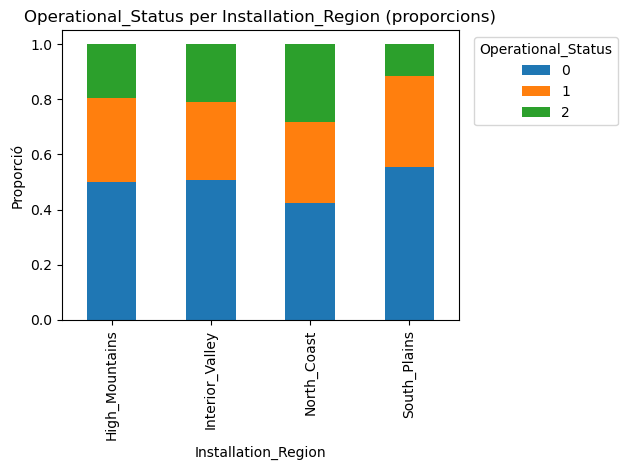


Distribució de Operational_Status condicionada a Turbine_Model:


Operational_Status,0,1,2
Turbine_Model,,,
Turbine_Model_A,0.521940,0.404157,0.073903
Turbine_Model_B,0.379141,0.333742,0.287117
Turbine_Model_C,0.720812,0.111675,0.167513
Turbine_Model_D,0.303202,0.370998,0.325800


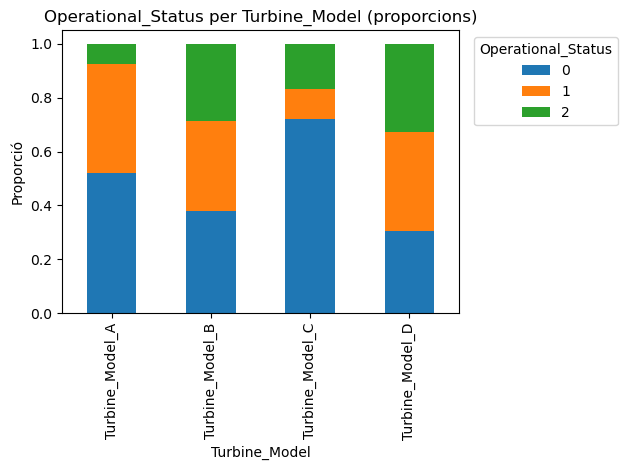

In [6]:
# Nosaltres fem taules de proporcions per fila (cada categoria -> distribució de classes)
for col in cat_cols:
    tab = pd.crosstab(df[col], df[TARGET], normalize="index")
    print(f"\nDistribució de {TARGET} condicionada a {col}:")
    display(tab)

    # Visualització apilada (stacked bar)
    ax = tab.plot(kind="bar", stacked=True)
    ax.set_title(f"{TARGET} per {col} (proporcions)")
    ax.set_xlabel(col)
    ax.set_ylabel("Proporció")
    plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Això ens ajuda a detectar si metadades (regió/model) estan molt associades al target 
# (pot ser útil, però també pot introduir “biaixos” o dependència del context).

# En el teu dataset, veiem diferències clares per Turbine_Model i per Installation_Region,
# cosa que apunta que aquestes variables poden ser importants. 

<span style="color: purple;"><b><i>
Correlacions i redundàncies (important abans de modelar)<br>
</i></b></span>


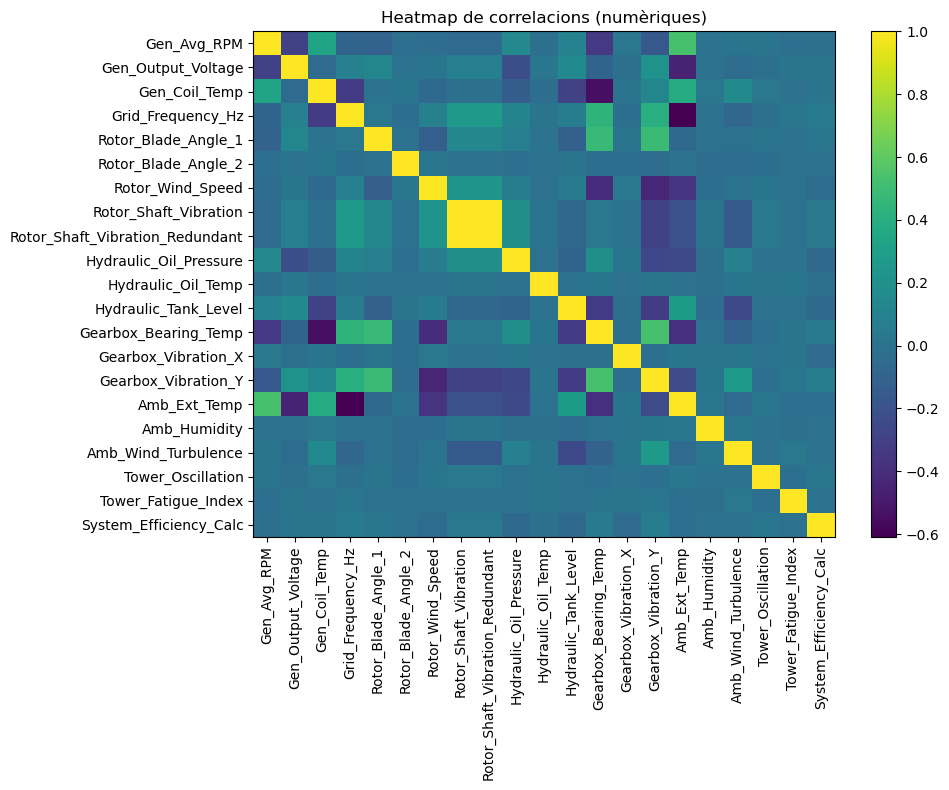

Rotor_Shaft_Vibration  Rotor_Shaft_Vibration_Redundant    1.0
dtype: float64

In [7]:
# Nosaltres calculem la correlació entre numèriques
corr = df[num_cols].corr()

# Heatmap bàsic amb matplotlib (sense seaborn)
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Heatmap de correlacions (numèriques)")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()

# Tot i que els ensembles poden tolerar correlació, una redundància perfecta és un senyal
# clar de variable duplicada.

# Busquem parelles molt correlacionades (p.ex. > 0.95)
abs_corr = corr.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)
display(high_pairs[high_pairs > 0.95].head(20))

# Troballa típica del ¡dataset: Rotor_Shaft_Vibration_Redundant és una còpia exacta de Rotor_Shaft_Vibration (correlació 1.0):
# - En neteja, nosaltres en deixarem només una per evitar duplicar senyal i distorsionar importàncies/decisions.0

# El fet que els dos sensors mesurin exactament el mateix, ens fa entendre també que el conjunt de dades és sintètic o almenys
# que aquests valors han estat creats sintèticament perquè és impossible que dos sensors redundants mesurin exactament el mateix
# en tots els moments.




<span style="color: purple;"><b><i>
Valors atípics (IQR) i variables “problemàtiques”<br>
</i></b></span>


System_Efficiency_Calc    0.056000
Gearbox_Vibration_Y       0.018333
Grid_Frequency_Hz         0.018000
Hydraulic_Oil_Pressure    0.016000
Gearbox_Bearing_Temp      0.015667
Hydraulic_Tank_Level      0.015333
Amb_Wind_Turbulence       0.014000
Gen_Output_Voltage        0.010000
Tower_Fatigue_Index       0.009667
Rotor_Blade_Angle_2       0.009667
dtype: float64

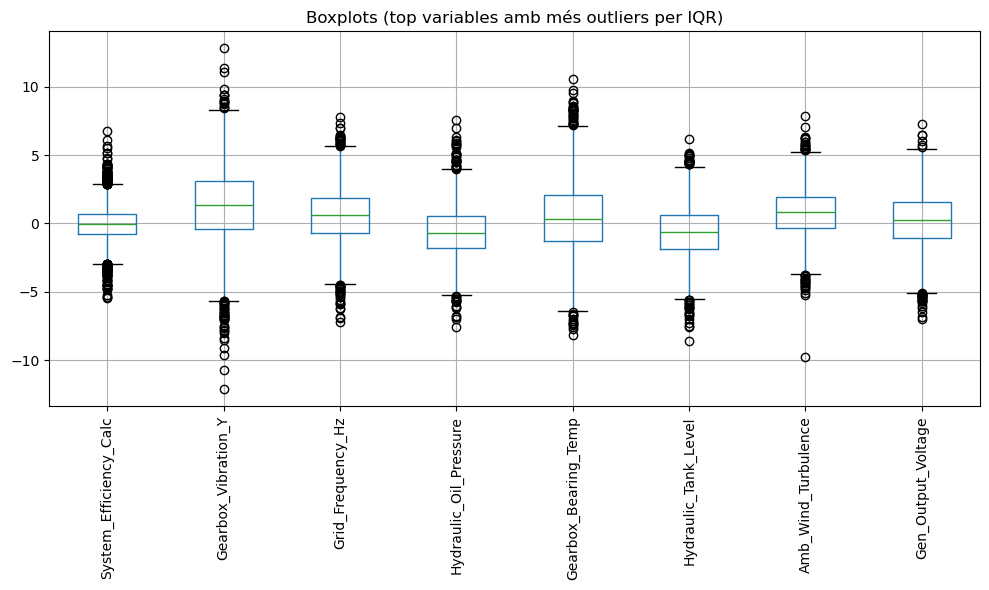

In [8]:
# Definim una funció d'outliers per IQR i fem un rànquing per columna
def outlier_fraction_iqr(s: pd.Series) -> float:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean()

outlier_frac = {c: outlier_fraction_iqr(df[c]) for c in num_cols}
outlier_rank = pd.Series(outlier_frac).sort_values(ascending=False)

display(outlier_rank.head(10))

# Se’ns demana explícitament analitzar atípics. A “Combinació de models” es comenta
# que alguns ensembles (especialment boosting) poden ser més sensibles a soroll i valors atípics

# Fem boxplots de les variables amb més atípics (top 8)
top_out = outlier_rank.head(8).index.tolist()

plt.figure(figsize=(10, 6))
df[top_out].boxplot(rot=90)
plt.title("Boxplots (top variables amb més outliers per IQR)")
plt.tight_layout()
plt.show()

# En el dataset, System_Efficiency_Calc és la que concentra més atípics per IQR,
# després apareixen variables com vibracions i pressions.)

<span style="color: purple;"><b><i>
“Importància” orientativa basada en EDA (sense entrenar un ensemble)<br>
</i></b></span>


Gearbox_Vibration_Y                 0.078975
Rotor_Blade_Angle_1                 0.066846
Turbine_Model_Turbine_Model_C       0.046521
Gearbox_Bearing_Temp                0.044289
Rotor_Wind_Speed                    0.038455
Amb_Wind_Turbulence                 0.037210
Hydraulic_Oil_Pressure              0.030537
Rotor_Shaft_Vibration_Redundant     0.030446
Rotor_Shaft_Vibration               0.030446
Gen_Output_Voltage                  0.027286
Turbine_Model_Turbine_Model_B       0.024333
Gearbox_Vibration_X                 0.022051
Turbine_Model_Turbine_Model_D       0.021768
Grid_Frequency_Hz                   0.020123
Installation_Region_South_Plains    0.015620
Turbine_Model_Turbine_Model_A       0.014884
Hydraulic_Tank_Level                0.013159
Gen_Avg_RPM                         0.010738
Amb_Humidity                        0.008881
Amb_Ext_Temp                        0.007232
dtype: float64

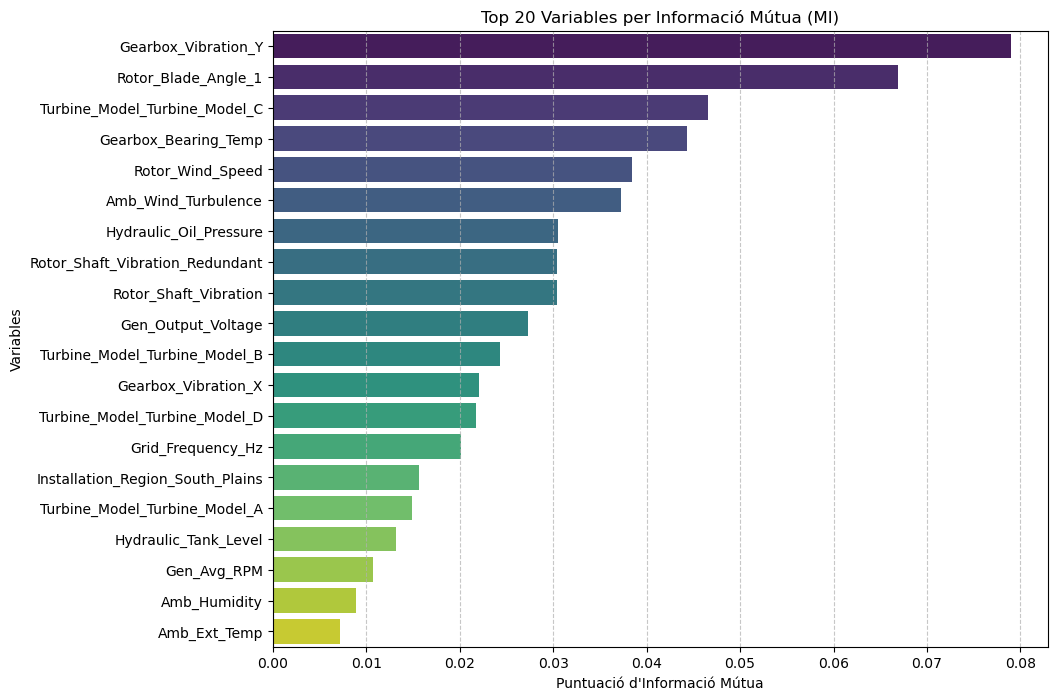

In [9]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop(columns=[TARGET])
y = df[TARGET]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X_enc = pre.fit_transform(X)

mi = mutual_info_classif(X_enc, y, random_state=42)

# Nosaltres recuperem noms de features (num + one-hot)
ohe = pre.named_transformers_["cat"]
feat_names = num_cols + ohe.get_feature_names_out(cat_cols).tolist()

mi_series = pd.Series(mi, index=feat_names).sort_values(ascending=False)
display(mi_series.head(20))

# Aquí fem una mesura exploratòria: Mutual Information (MI). No és “la veritat absoluta”,
# però ens dona una pista de quines variables tenen més dependència amb el target.

# Com ho llegim: 
# - Si surten molt amunt variables de vibració (gearbox/shaft), angles de pala, temperatures i metadades
# (model/regió), és coherent amb la descripció per subsistemes del dataset. 

# Aquest rànquing ens servirà per justificar “variables candidates” i per preparar la discussió de la PAC.


# Fem servir un gràfic de barres horitzontals.
# Aquest gràfic permet veure ràpidament quina és la "distància" d'importància entre les variables.

plt.figure(figsize=(10, 8))

# Assignem l'índex a 'hue', posem 'legend=False' i mantenim la paleta
sns.barplot(
    x=mi_series.head(20).values, 
    y=mi_series.head(20).index, 
    hue=mi_series.head(20).index,  # Assignem la variable al color
    palette='viridis', 
    legend=False                   # Treiem la llegenda perquè ja tenim els noms a l'eix Y
)

plt.title('Top 20 Variables per Informació Mútua (MI)')
plt.xlabel('Puntuació d\'Informació Mútua')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Anàlisi crítica (només amb EDA): reptes i variables candidates<br>
</i></b></span>

<ul>
  <li><b>Qualitat i estructura del dataset</b><br>
    Hem observat un dataset de <b>3000 files</b> i <b>24 columnes</b>, amb <b>2 variables categòriques</b> (<i>Installation_Region</i>, <i>Turbine_Model</i>) i la resta majoritàriament <b>numèriques</b> (float64), i el target <i>Operational_Status</i> com a <b>int64</b>.<br>
    També hem comprovat que hi ha <b>0 valors nuls</b> i <b>0 files duplicades</b>, de manera que, a nivell bàsic, les dades tenen una qualitat estructural bona.
  </li>

  <li><b>Distribució del target (desbalanceig)</b><br>
    Veiem que el target <i>Operational_Status</i> no és uniforme: <b>classe 0</b> ≈ 49.67% (1490), <b>classe 1</b> ≈ 30.23% (907) i <b>classe 2</b> ≈ 20.10% (603).<br>
    Això indica un <b>desbalanceig moderat</b>, i per tant hem de ser curosos a l’hora d’interpretar rendiment (una mètrica global pot amagar un pitjor comportament en la classe minoritària).
  </li>

  <li><b>Metadades amb diferències clares per classe (Installation_Region i Turbine_Model)</b><br>
    Hem detectat que la distribució de classes canvia segons <i>Installation_Region</i> (p. ex. <i>North_Coast</i> té una proporció de classe 2 notablement més alta que <i>South_Plains</i>).<br>
    Encara més, <i>Turbine_Model</i> mostra canvis molt marcats: per exemple, <i>Turbine_Model_A</i> té una proporció de classe 2 molt baixa, mentre que <i>Turbine_Model_D</i> presenta una proporció de classe 2 elevada.<br>
    Per tant, concloem que aquestes variables categòriques tenen <b>senyal discriminatiu</b> (estan associades a canvis en l’estat operatiu).
  </li>

  <li><b>Redundància perfecta entre variables</b><br>
    Hem confirmat una <b>correlació 1.0</b> entre <i>Rotor_Shaft_Vibration</i> i <i>Rotor_Shaft_Vibration_Redundant</i>.<br>
    Això implica que una de les dues columnes és <b>duplicada</b> i, si la mantenim, podríem estar duplicant el mateix senyal dins del conjunt de variables.
  </li>

  <li><b>Patrons de correlació (dependències entre sensors)</b><br>
    A partir del heatmap, veiem correlacions en general <b>moderades</b> entre moltes variables, amb alguna dependència més marcada en el bloc de vibracions (incloent el cas redundant).<br>
    Això suggereix que hi ha <b>informació compartida</b> entre alguns sensors, però no una col·linealitat extrema generalitzada (més enllà del cas redundant).
  </li>

  <li><b>Valors atípics (outliers) segons IQR</b><br>
    Hem observat que hi ha variables amb una proporció d’atípics més alta segons la regla de l’IQR, destacant <i>System_Efficiency_Calc</i> i <i>Gearbox_Vibration_Y</i>, i també variables com <i>Grid_Frequency_Hz</i>, <i>Hydraulic_Oil_Pressure</i>, <i>Gearbox_Bearing_Temp</i>, <i>Hydraulic_Tank_Level</i>, <i>Amb_Wind_Turbulence</i> i <i>Gen_Output_Voltage</i>.<br>
    Això indica que el dataset conté <b>cues</b> (valors extrems) en diverses variables i, per tant, hem de considerar-ho a l’hora de tractar dades i validar models (perquè alguns errors poden venir d’aquests extrems).
  </li>

  <li><b>Variables candidates segons Informació Mútua (MI)</b><br>
    Segons el rànquing de MI, identifiquem com a més informatives (entre les top):<br>
    <b>(1)</b> <i>Gearbox_Vibration_Y</i>, <b>(2)</b> <i>Rotor_Blade_Angle_1</i>, <b>(3)</b> la dummy de <i>Turbine_Model_C</i>, <b>(4)</b> <i>Gearbox_Bearing_Temp</i>, <b>(5)</b> <i>Rotor_Wind_Speed</i>, <b>(6)</b> <i>Amb_Wind_Turbulence</i>, i també <i>Hydraulic_Oil_Pressure</i>, <i>Gen_Output_Voltage</i> i les variables de vibració de l’eix (incloent la redundant).<br>
    Això reforça la idea que la informació més útil per predir l’estat operatiu prové, sobretot, de <b>vibracions</b>, <b>angles/vent</b>, <b>temperatures</b> i <b>metadades del model de turbina</b>.
  </li>

  <li><b>Conclusió crítica (EDA)</b><br>
    A partir de l’EDA, concloem que el problema presenta <b>desbalanceig moderat del target</b>, <b>senyal fort a metadades</b> (regió/model), <b>una redundància perfecta</b> en una variable de vibració, i <b>presència d’atípics</b> en múltiples sensors.<br>
    També veiem que la relació entre sensors i estat operatiu sembla <b>multifactorial</b>, amb diverses famílies de variables aportant informació (vibració, rotor/vent, temperatura i variables elèctriques).
  </li>
</ul>

</i></b></span>


<span style="color: purple;"><b><i>
<b>Preparació i justificació de dades (Classificació)</b><br><br>
<ul>
  <li><b>Objectiu</b><br>
    Preparem les dades per entrenar classificadors, assegurant: <b>(1)</b> codificació correcta de categòriques, <b>(2)</b> tractament coherent de numèriques, <b>(3)</b> gestió d’atípics sense “trencar” el senyal, i <b>(4)</b> evitar fuga de dades amb una divisió Train/Test i fit del preprocessament només amb Train (llavor <b>42</b>).
  </li>

  <li><b>Justificació (basada en la nostra EDA)</b><br>
    Hem vist: <b>0 nuls</b> i <b>0 duplicats</b> (però mantenim imputació “defensiva”), <b>desbalanceig moderat</b> del target, presència d’<b>outliers</b> (IQR) en diverses variables i una <b>redundància perfecta</b> entre <i>Rotor_Shaft_Vibration</i> i <i>Rotor_Shaft_Vibration_Redundant</i>.<br>
    A més, l’enunciat ens exigeix explícitament justificar codificació, escalament/normalització i evitar fuga de dades amb llavor 42.
  </li>

  <li><b>Decisions de transformació</b><br>
    <ul>
      <li><b>Eliminem la variable redundant</b> (<i>Rotor_Shaft_Vibration_Redundant</i>) per evitar duplicar el mateix senyal.</li>
      <li><b>Categòriques</b> (<i>Installation_Region</i>, <i>Turbine_Model</i>): fem <b>One-Hot Encoding</b> per convertir-les en variables numèriques utilitzables pels models.</li>
      <li><b>Numèriques</b>: fem un <b>escalament robust (RobustScaler)</b> perquè l’EDA mostra presència d’atípics (això redueix l’impacte dels extrems, sense eliminar registres que poden ser informatius).</li>
      <li><b>Transformacions no lineals</b>: no les apliquem perquè les variables estan centrades i poden tenir valors negatius (log/BoxCox no seria adequat directament). Si calgués, exploraríem alternatives (p. ex. quantile transform) més endavant.</li>
      <li><b>Evitem fuga de dades</b>: la divisió Train/Test i el preprocessament s’encaixen en un Pipeline/ColumnTransformer, de manera que el fit es fa només amb Train.</li>
    </ul>
  </li>
</ul>
</i></b></span>


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# --- 1) Carreguem dades ---
df = pd.read_csv("wind_turbine_data.csv")

# --- 2) Definim target ---
TARGET = "Operational_Status"

# --- 3) Eliminem la variable redundant detectada a l’EDA (correlació 1.0) ---
# Eliminem només si existeix, per fer el codi robust.
redundant_col = "Rotor_Shaft_Vibration_Redundant"
if redundant_col in df.columns:
    df = df.drop(columns=[redundant_col])

# --- 4) Separem X i y ---
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)  # Assegurem tipus enter per multiclass (0/1/2)

# --- 5) Identifiquem columnes categòriques i numèriques ---
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categòriques:", cat_cols)
print("Numèriques:", len(num_cols))

# --- 6) Split Train/Test amb estratificació (per respectar el desbalanceig moderat) ---
# IMPORTANT: llavor = 42, i estratifiquem per mantenir proporcions de classe.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# --- 7) Pipeline de preprocessament ---
# Numèriques:
# - Imputació "defensiva" (tot i que l’EDA mostra 0 nuls, evitem errors futurs)
# - RobustScaler per reduir l’impacte d’outliers (detectats per IQR)
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Categòriques:
# - Imputació "defensiva"
# - OneHotEncoder per passar a format numèric (i evitar problemes amb categories noves)
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer:
# Apliquem la transformació adequada a cada tipus de variable.
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"  # Descartem qualsevol columna no llistada
)

# --- 8) Fit només amb TRAIN (evitem fuga de dades) i transformem TRAIN/TEST ---
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep  = preprocess.transform(X_test)

print("X_train_prep:", X_train_prep.shape)
print("X_test_prep :", X_test_prep.shape)

# --- 9) Recuperem noms de features finals (útil per interpretació/feature importance) ---
feature_names = preprocess.get_feature_names_out()
print("Nombre de features finals:", len(feature_names))
print("Exemple de features:", feature_names[:15])


Categòriques: ['Installation_Region', 'Turbine_Model']
Numèriques: 20
Train: (2400, 22) (2400,)
Test : (600, 22) (600,)
X_train_prep: (2400, 28)
X_test_prep : (600, 28)
Nombre de features finals: 28
Exemple de features: ['num__Gen_Avg_RPM' 'num__Gen_Output_Voltage' 'num__Gen_Coil_Temp'
 'num__Grid_Frequency_Hz' 'num__Rotor_Blade_Angle_1'
 'num__Rotor_Blade_Angle_2' 'num__Rotor_Wind_Speed'
 'num__Rotor_Shaft_Vibration' 'num__Hydraulic_Oil_Pressure'
 'num__Hydraulic_Oil_Temp' 'num__Hydraulic_Tank_Level'
 'num__Gearbox_Bearing_Temp' 'num__Gearbox_Vibration_X'
 'num__Gearbox_Vibration_Y' 'num__Amb_Ext_Temp']


<span style="color: purple;"><b><i>
Comprovació ràpida (per veure categories i les columnes one-hot)<br>
</i></b></span>


In [11]:
# Categories presents a cada columna categòrica
for c in cat_cols:
    print(f"\n{c} (n categories):", df[c].nunique())
    print(df[c].value_counts())

# Noms de features generades (especialment les categòriques one-hot)
feature_names = preprocess.get_feature_names_out()
print("\nTotal features finals:", len(feature_names))

# Mostrem només les one-hot (les que comencen per 'cat__')
onehot_feats = [f for f in feature_names if f.startswith("cat__")]
print("\nFeatures one-hot:")
for f in onehot_feats:
    print(" -", f)



Installation_Region (n categories): 4
Installation_Region
South_Plains       750
High_Mountains     750
Interior_Valley    750
North_Coast        750
Name: count, dtype: int64

Turbine_Model (n categories): 4
Turbine_Model
Turbine_Model_A    866
Turbine_Model_B    815
Turbine_Model_C    788
Turbine_Model_D    531
Name: count, dtype: int64

Total features finals: 28

Features one-hot:
 - cat__Installation_Region_High_Mountains
 - cat__Installation_Region_Interior_Valley
 - cat__Installation_Region_North_Coast
 - cat__Installation_Region_South_Plains
 - cat__Turbine_Model_Turbine_Model_A
 - cat__Turbine_Model_Turbine_Model_B
 - cat__Turbine_Model_Turbine_Model_C
 - cat__Turbine_Model_Turbine_Model_D


<span style="color: purple;"><b><i>
Anàlisi Crítica: Reflexió sobre l'Ús d'I.A. Generativa
</i></b></span>


<ul>
  <li><b>Quina eina d’I.A. he utilitzat i per a quines tasques?</b><br>
    He utilitzat <b>ChatGPT</b> com a assistent durant l’EDA i la preparació de dades.<br>
    Les tasques concretes on m’ha ajudat han estat:<br>
    <ul>
      <li>Proposar un <b>guió d’EDA</b> (checks de tipus de dades, nuls/duplicats, distribució del target, anàlisi de categòriques vs target, correlacions, outliers amb IQR i ranking).</li>
      <li>Proposar codi per fer <b>visualitzacions</b> (barplots del target, barplots apilats per variables categòriques, heatmap de correlació, boxplots).</li>
      <li>Proposar una <b>preparació de dades</b> segura amb <b>Pipeline + ColumnTransformer</b> per evitar fuga de dades, incloent <b>One-Hot Encoding</b> per variables categòriques i <b>escalat robust</b> per numèriques amb outliers.</li>
      <li>Ajudar a convertir conclusions de l’EDA en una <b>anàlisi crítica redactada</b> (basada en els resultats observats).</li>
    </ul>
  </li>

  <li><b>Suggeriments erronis o enganyosos i com els he corregit</b><br>

<ul>
  <li><b>Error/limitació 1: conclusions “massa automàtiques” sense lligar-les directament a evidències mostrades</b><br>
    En alguns moments, l’I.A. pot redactar conclusions amb to categòric abans que s’hagin documentat explícitament al document final (taules/gràfics).<br>
    <b>Correcció:</b> he revisat la redacció per assegurar que cada afirmació queda vinculada a una sortida concreta del notebook (p. ex. la taula i el gràfic de distribució del target). Només he mantingut xifres i patrons quan apareixen a les sortides executades (per exemple, el recompte de classes 0/1/2).
<br>

  <li><b>Decisió discutible 3: imputació si no hi ha valors nuls</b><br>
    L’I.A. tendeix a proposar pipelines genèrics amb imputació encara que l’EDA indiqui <b>0 nuls</b> al dataset.<br>
    <b>Correcció:</b> he deixat clar que, amb aquestes dades, la imputació no és necessària per “netejar” el dataset, i l’he mantingut només com a mesura de robustesa del pipeline (per evitar errors si en algun pas posterior apareixen nuls o si s’afegeixen noves dades).
  </li>
</ul>

</i></b></span>

  </li>

  <li><b>Conclusió: principal risc de delegar l’anàlisi completament a una I.A.</b><br>
    El principal risc és que la I.A. pot generar una anàlisi <b>plausible però incorrecta</b> (“hallucinations”): pot afirmar patrons, percentatges, o justificacions sense haver-los contrastat amb les sortides reals, o pot proposar transformacions “de manual” que no són adequades per a la distribució concreta de les dades.<br>
    Per això, l’I.A. s’ha d’utilitzar com a <b>copilot</b> (guia i accelerador), però la validació final (xifres, gràfics, coherència amb l’enunciat i impacte en el model) s’ha de fer sempre contrastant amb els resultats executats al notebook.
  </li>
</ul>

</i></b></span>



## 2. Entrenament i Avaluació de Models Base (1 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Entrena amb el conjunt de dades d'entrenament i valida amb el conjunt de dades de validació els següents models base (Guarda les prediccions per al seu ús més endavant):
   * Regressió Logística (`LogisticRegression`)
   * Arbre de Decisió (`DecisionTreeClassifier`)
   * K veïns més propers (`KNeighborsClassifier`)
   * Classificador Naïve-Bayes (`GaussianNB`)
2. Per a cada model, reporta les mètriques obtingudes de la validació que consideris necessàries.
3. **Anàlisi Crítica:** Comenta breument el rendiment dels models base. Quina de les mètriques consideres més informativa per avaluar el rendiment i per què? Justifica la teva resposta.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>

</div>

<span style="color: purple;"><b><i>
Entrena amb el conjunt de dades d'entrenament i valida amb el conjunt de dades de validació els següents models base (Guarda les prediccions per al seu ús més endavant):
</i></b></span>

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix


# --- 1) Definim explícitament què és Train i què és Validació ---
# (En el nostre flux actual, el que anomenàvem "test" el fem servir com a validació de la PAC.)
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test


# --- 2) Definim els 4 models base tal com demana l’enunciat ---
base_estimators = {
    "LogReg": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "GaussianNB": GaussianNB()
}


# --- 3) Funció d'avaluació per un model ---
def evalua_model(model_name: str, pipe: Pipeline, X_val, y_val):
    """Retorna mètriques i prediccions per reutilitzar-les després."""
    # Predicció de classe
    y_pred = pipe.predict(X_val)

    # Predicció de probabilitats (aquests 4 models la suporten)
    y_proba = pipe.predict_proba(X_val)

    # Mètriques (incloem F1 macro perquè és útil en multiclass amb certa descompensació)
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
    }

    # Matriu de confusió
    cm = confusion_matrix(y_val, y_pred)

    return metrics, y_pred, y_proba, cm

# --- 4) Entrenem, validem i guardem resultats/prediccions ---
base_models = {}      # pipelines entrenats
base_predictions = {} # prediccions guardades per reutilitzar
metrics_list = []     # per resumir en una taula

for name, clf in base_estimators.items():
    # Pipeline complet: preprocessament + model
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", clf)
    ])

    # Entrenament
    pipe.fit(X_tr, y_tr)

    # Avaluació a validació
    metrics, y_val_pred, y_val_proba, cm = evalua_model(name, pipe, X_val, y_val)

    # Guardem pipeline i prediccions
    base_models[name] = pipe
    base_predictions[name] = {
        "y_val_pred": y_val_pred,
        "y_val_proba": y_val_proba,
        "confusion_matrix": cm
    }
    metrics_list.append(metrics)

    # Mostrem resultats detallats per model (útil per la discussió crítica)
    print(f"\n===== {name} =====")
    print("Mètriques:", metrics)
    print("Matriu de confusió:\n", cm)
    print("\nClassification report:\n", classification_report(y_val, y_val_pred, digits=4))


# --- 5) Resum comparatiu en una taula ---
results_df = pd.DataFrame(metrics_list).sort_values(by="f1_macro", ascending=False)
display(results_df)

# Frase-resum (per recordatori ràpid): 
#  F1: equilibra “encerts del que dic” (precisió) i “els que no se m’escapen” (recall - sensibilitat).
#  F1 macro: tracta totes les classes igual (clau amb classe 2 minoritària).
#  KNN: millor global perquè aprofita distàncies (dades escalades) i no-linealitat.
#  GNB: millor per “trobar failures” (classe 2), però menys estable globalment.
#  LogReg: estable però lineal (costa amb patrons complexos).
#  Arbre: regles potents però pot fallar sense ajustos.


# --- 6) Afegim matriu de confusió normalitzada ---

# Calculem i mostrem la matriu de confusió normalitzada per cada model base. (què falla exactament)
# Les diagonals són el recall per classe. (0-1-2)
for name in base_predictions.keys():
    y_pred_model = base_predictions[name]["y_val_pred"]

    cm = confusion_matrix(y_val, y_pred_model)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    print(f"\n===== {name} | Matriu de confusió normalitzada (per classe real) =====")
    print(np.round(cm_norm, 3))





===== LogReg =====
Mètriques: {'model': 'LogReg', 'accuracy': 0.6633333333333333, 'balanced_accuracy': np.float64(0.5963032037498007), 'f1_macro': np.float64(0.6003112930312595), 'f1_weighted': np.float64(0.6496921253844441)}
Matriu de confusió:
 [[237  37  24]
 [ 48 123  10]
 [ 51  32  38]]

Classification report:
               precision    recall  f1-score   support

           0     0.7054    0.7953    0.7476       298
           1     0.6406    0.6796    0.6595       181
           2     0.5278    0.3140    0.3938       121

    accuracy                         0.6633       600
   macro avg     0.6246    0.5963    0.6003       600
weighted avg     0.6500    0.6633    0.6497       600


===== DecisionTree =====
Mètriques: {'model': 'DecisionTree', 'accuracy': 0.6116666666666667, 'balanced_accuracy': np.float64(0.578407950685549), 'f1_macro': np.float64(0.5795115738968035), 'f1_weighted': np.float64(0.6110001391090266)}
Matriu de confusió:
 [[203  48  47]
 [ 54 110  17]
 [ 46  21  

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
2,KNN,0.755000,0.683967,0.701651,0.741162
3,GaussianNB,0.658333,0.632065,0.626753,0.662299
0,LogReg,0.663333,0.596303,0.600311,0.649692
1,DecisionTree,0.611667,0.578408,0.579512,0.611000



===== LogReg | Matriu de confusió normalitzada (per classe real) =====
[[0.795 0.124 0.081]
 [0.265 0.68  0.055]
 [0.421 0.264 0.314]]

===== DecisionTree | Matriu de confusió normalitzada (per classe real) =====
[[0.681 0.161 0.158]
 [0.298 0.608 0.094]
 [0.38  0.174 0.446]]

===== KNN | Matriu de confusió normalitzada (per classe real) =====
[[0.909 0.067 0.023]
 [0.249 0.729 0.022]
 [0.347 0.24  0.413]]

===== GaussianNB | Matriu de confusió normalitzada (per classe real) =====
[[0.718 0.121 0.161]
 [0.21  0.641 0.149]
 [0.215 0.248 0.537]]


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>


<span style="color: purple;"><b><i>
<b>Anàlisi crítica — Rendiment dels models base i mètrica més informativa</b><br><br>

<ul>
  <li><b>Rendiment global (comparació de models base)</b><br>
    Observem que <b>KNN</b> és el model amb millor rendiment global en validació (accuracy ≈ 0.755 i F1 macro ≈ 0.702), seguit de <b>GaussianNB</b> (accuracy ≈ 0.658 i F1 macro ≈ 0.627).<br>
    La <b>Regressió Logística</b> queda en una posició intermèdia (accuracy ≈ 0.663 però F1 macro ≈ 0.600), i l’<b>Arbre de Decisió</b> és el que rendeix pitjor (accuracy ≈ 0.612 i F1 macro ≈ 0.580).
  </li>

  <li><b>Què ens diuen les matrius de confusió normalitzades?</b><br>
    El principal repte és la <b>classe 2 (Failure)</b>, que és la minoritària. Tot i que KNN és el millor globalment, el recall de la classe 2 es manté moderat (≈ 0.413), ja que una part important dels “2” es confonen amb “0”.<br>
    GaussianNB destaca perquè recupera millor la classe 2 (recall ≈ 0.537), però perd rendiment en les classes 0 i 1, i per això queda per sota en el conjunt de mètriques.
  </li>

  <li><b>Mètrica més informativa: F1 macro (i per què)</b><br>
    Considerem que la mètrica més informativa és el <b>F1 macro</b> perquè dona el <b>mateix pes a cada classe</b>, independentment de quantes mostres tingui. Això és especialment important en aquest problema, on el target està <b>moderadament desbalancejat</b> i ens interessa detectar correctament també la classe 2 (Failure).<br>
    L’<b>accuracy</b> pot ser enganyosa en situacions de desbalanceig, perquè es pot obtenir un valor alt encertant sobretot la classe majoritària, encara que el model falli massa en la classe minoritària. En canvi, el <b>F1 macro</b> penalitza aquest comportament i reflecteix millor el rendiment “equilibrat” del classificador.
  </li>
</ul>

</i></b></span>


## 3. Combinació paral·lela de classificadors de base similar: Bagging (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `RandomForestClassifier`.
2. Realitza una cerca i ajust (*tuning*) d'hiperparàmetres clau (n_estimators, max_depth, max_features) utilitzant validació creuada (p. ex., GridSearchCV o RandomizedSearchCV amb 5-CV). Defineix un rang de cerca raonable per a cada hiperparàmetre i usa la mètrica que has justificat com a més informativa en el punt anterior per a l'optimització.
3. Reporta els millors hiperparàmetres trobats i la puntuació (*score*) de validació creuada obtinguda amb ells.
   
</div>

 RESUM RECORDATORI FONAMENTS: Arbres de decisió I Random Forest
 Arbres de decisió: Ni han de dos tipus, als arbres de decisió que classifiquen les
dades del conjunt d’entrada en funció d’una variable classificadora categòrica
(és a dir, que pren un conjunt finit de valors) s’anomenen arbres de classificació.
Si la variable classificadora és contínua, parlaríem d’arbres de regressió.
Tots dos tipus d’arbres de decisió donen el nomcomú CART (Classification and
Regression Trees).
Arbres de classificació: Identificada la variable objectiu (Target), en cada nús  de decisió, s'individua (de dalt cap a baix), quin atribut (variable) del conjunt de dades, classifica, és la més important o rellevant en % de variació de la variable target discreta. 
Random Forest: Els paràmetres que rep l’algorisme inclouen
el nombre d’arbres al bosc (T), el nombre de característiques a considerar en
buscar la millor divisió a cada node de l’arbre (normalment m′ ≤ √m o m′ ≤
log2m), que es denota com a m′, i el nombre de mostres que cal considerar
per a entrenar cada arbre (seleccionades aleatòriament amb reemplaçament),
indicat com a n′, que és habitualment n.

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Implementa RandomForestClassifier.
Realitza una cerca i ajust (tuning) d'hiperparàmetres clau (n_estimators, max_depth, max_features) utilitzant validació creuada (p. ex., GridSearchCV o RandomizedSearchCV amb 5-CV). Defineix un rang de cerca raonable per a cada hiperparàmetre i usa la mètrica que has justificat com a més informativa en el punt anterior per a l'optimització.
</i></b></span>

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV

# ============================================================
# 1) Definim Train i Validació
#    (X_test/y_test els fem servir com a validació amb el conjunt d evalidació
#     final del model).
# ============================================================
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ============================================================
# 2) Pipeline: preprocessament + RandomForest
#    - Evitem fuga de dades: el preprocessament es fa DINS del CV.
#    - RandomForest no necessita escalat, però mantenim el preprocessament
#      comú (one-hot + robust scaler) per consistència amb la resta.
# ============================================================
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

# ============================================================
# 3) Definim validació creuada estratificada (5-CV)
#    - Estratifiquem per mantenir proporcions de classes a cada fold.
# ============================================================
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4) Espai de cerca "raonable" d'hiperparàmetres
#    - n_estimators: més arbres -> menys variància (fins a un punt).
#    - max_depth: controla complexitat / sobreajust.
#    - max_features: controla diversitat entre arbres (sqrt/log2 són valors típics).
# ============================================================

param_grid = {
    "model__n_estimators": [200, 400, 600, 800, 1000],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__max_features": ["sqrt", "log2", 0.5, 0.75]
}

# ============================================================
# 5) Cerca i ajust d'hiperparàmetres
#    - Optimitzem F1 macro (multiclasse, pondera igual totes les classes).
#    - Pots triar GridSearchCV (exhaustiu) o RandomizedSearchCV (més ràpid).
# ============================================================

USE_RANDOMIZED = False  # canviar a True si volem RandomizedSearchCV

if USE_RANDOMIZED:
    # RandomizedSearch: prova un nombre fix de combinacions aleatòries
    search = RandomizedSearchCV(
        estimator=rf_pipe,
        param_distributions=param_grid,
        n_iter=30,                 # nombre de combinacions a provar (ajusta si vols)
        scoring="f1_macro",
        cv=cv5,
        n_jobs=-1,
        verbose=2,
        random_state=42,
        return_train_score=True
    )
else:
    # GridSearch: prova totes les combinacions (triga més)
    search = GridSearchCV(
        estimator=rf_pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv5,
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

# Entrenem la cerca sobre tot el conjunt d'entrenament
search.fit(X_tr, y_tr)

# ============================================================
# 6) Report: millors hiperparàmetres i millor score de CV
# ============================================================
print("\nMillors hiperparàmetres trobats:")
print(search.best_params_)

print("\nMillor puntuació de validació creuada (F1 macro):")
print(search.best_score_)

# ============================================================
# 7) Guardem el millor model per l’apartat següent
#    - El millor estimator ja porta preprocessament + RF entrenat amb CV intern.
# ============================================================
rf_best = search.best_estimator_

# ============================================================
# 8) Taula amb els millors resultats del CV
# ============================================================
cv_results = pd.DataFrame(search.cv_results_)

cols = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "param_model__n_estimators", "param_model__max_depth", "param_model__max_features"
]
cv_results_top = cv_results[cols].sort_values("rank_test_score").head(10)

display(cv_results_top)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


C:\Users\comum\.conda\envs\environment_uoc20251pec4_V2\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Millors hiperparàmetres trobats:
{'model__max_depth': None, 'model__max_features': 0.5, 'model__n_estimators': 1000}

Millor puntuació de validació creuada (F1 macro):
0.7486940736519668


,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__max_features
14,1,0.748694,0.018837,1000,None,0.5
74,1,0.748694,0.018837,1000,30,0.5
94,1,0.748694,0.018837,1000,40,0.5
54,4,0.747864,0.016811,1000,20,0.5
53,5,0.745626,0.017054,800,20,0.5
93,6,0.744675,0.015414,800,40,0.5
73,6,0.744675,0.015414,800,30,0.5
13,6,0.744675,0.015414,800,None,0.5
52,9,0.744485,0.015124,600,20,0.5
12,10,0.744069,0.015485,600,None,0.5


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Reporta els millors hiperparàmetres trobats i la puntuació (score) de validació creuada obtinguda amb ells.
</i></b></span>

<span style="color: purple;"><b><i>
<b>Bagging (RandomForest) — Tuning amb GridSearchCV i 5-CV</b><br><br>

<ul>
  <li><b>Configuració del procés</b><br>
    S’ha ajustat un <i>RandomForestClassifier</i> mitjançant <b>GridSearchCV</b> amb <b>validació creuada estratificada de 5 folds</b>.<br>
    Com a funció d’optimització s’ha utilitzat <b>F1 macro</b>, ja que és la mètrica més informativa en aquest problema multiclasse amb desbalanceig moderat, perquè dona el mateix pes a totes les classes.
  </li>

  <li><b>Rangs de cerca (hiperparàmetres clau)</b><br>
    S’han explorat combinacions raonables per als hiperparàmetres clau del Random Forest:<br>
    <ul>
      <li><i>n_estimators</i> (nombre d’arbres): valors entre 200 i 1000.</li>
      <li><i>max_depth</i> (profunditat màxima): {None, 10, 20, 30, 40}.</li>
      <li><i>max_features</i> (nombre/proporció de variables candidates a cada split): {sqrt, log2, 0.5, 0.75}.</li>
    </ul>
  </li>

  <li><b>Millors hiperparàmetres trobats</b><br>
    <ul>
      <li><b>n_estimators = 1000</b></li>
      <li><b>max_depth = None</b></li>
      <li><b>max_features = 0.5</b></li>
    </ul>
  </li>

  <li><b>Puntuació (score) de validació creuada amb els millors hiperparàmetres</b><br>
    La millor puntuació obtinguda en <b>5-CV</b> ha estat:<br>
    <b>F1 macro = 0.7487</b>
  </li>

  <li><b>Comentari breu del resultat</b><br>
    El fet que <i>max_features = 0.5</i> aparegui com a millor opció suggereix que augmentar la diversitat entre arbres (fent que cada arbre vegi subconjunts diferents de variables en cada partició) contribueix a millorar la generalització. A més, l’ús de <i>n_estimators</i> alt (1000) redueix la variància del model i estabilitza el rendiment en validació creuada.
  </li>
</ul>

</i></b></span>


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

4. Valida (amb el conjunt de dades de validació) el model Random Forest final (entrenat amb els millors hiperparàmetres sobre tot el set d'entrenament).
5. Mostra un gràfic de la importància de les característiques (feature_importance_) del model final.
6. **Anàlisi Crítica:** Compara el rendiment del teu Random Forest optimitzat amb els models base (refereix-te als valors específics de les mètriques que has obtingut). Ha aconseguit RF una millora substancial, especialment en les classes minoritàries? Analitza el teu gràfic d'importància de característiques: Quines variables semblen ser les més rellevants segons RF? Té sentit aquest resultat? Identifica RF algunes de les variables categòriques que s'havien identificat com a importants?
   
</div>

<span style="color: purple;"><b><i>
<b>Validació del Random Forest final i importància de característiques</b><br><br>
<ul>
  <li>Segons l’enunciat, cal validar el <b>Random Forest final</b> (entrenat amb els millors hiperparàmetres sobre tot el conjunt d’entrenament) amb el conjunt de validació, i mostrar el gràfic de <b>feature_importance_</b>.</li>
  <li>Com a mètrica principal d’avaluació fem servir <b>F1 macro</b> (optimitzada també al tuning amb 5-CV).</li>
</ul>
</i></b></span>


<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

Millors hiperparàmetres: {'model__max_depth': None, 'model__max_features': 0.5, 'model__n_estimators': 1000}
Millor score 5-CV (F1 macro): 0.7486940736519668

===== RandomForest (validació amb test) =====
accuracy: 0.7783
balanced_accuracy: 0.7139
f1_macro: 0.7294
f1_weighted: 0.7663

Matriu de confusió:
 [[269  18  11]
 [ 35 145   1]
 [ 41  27  53]]

Classification report:
               precision    recall  f1-score   support

           0     0.7797    0.9027    0.8367       298
           1     0.7632    0.8011    0.7817       181
           2     0.8154    0.4380    0.5699       121

    accuracy                         0.7783       600
   macro avg     0.7861    0.7139    0.7294       600
weighted avg     0.7819    0.7783    0.7663       600


Matriu de confusió normalitzada (per classe real):
 [[0.903 0.06  0.037]
 [0.193 0.801 0.006]
 [0.339 0.223 0.438]]


,feature,importance
0,num__Gearbox_Vibration_Y,0.106421
1,num__Rotor_Blade_Angle_1,0.072686
2,num__Hydraulic_Oil_Pressure,0.068796
3,num__Grid_Frequency_Hz,0.064549
4,num__Gen_Output_Voltage,0.062920
5,num__Rotor_Wind_Speed,0.059729
6,num__Gen_Avg_RPM,0.057104
7,num__Amb_Wind_Turbulence,0.056842
8,num__Rotor_Shaft_Vibration,0.048403
9,num__Gen_Coil_Temp,0.045596


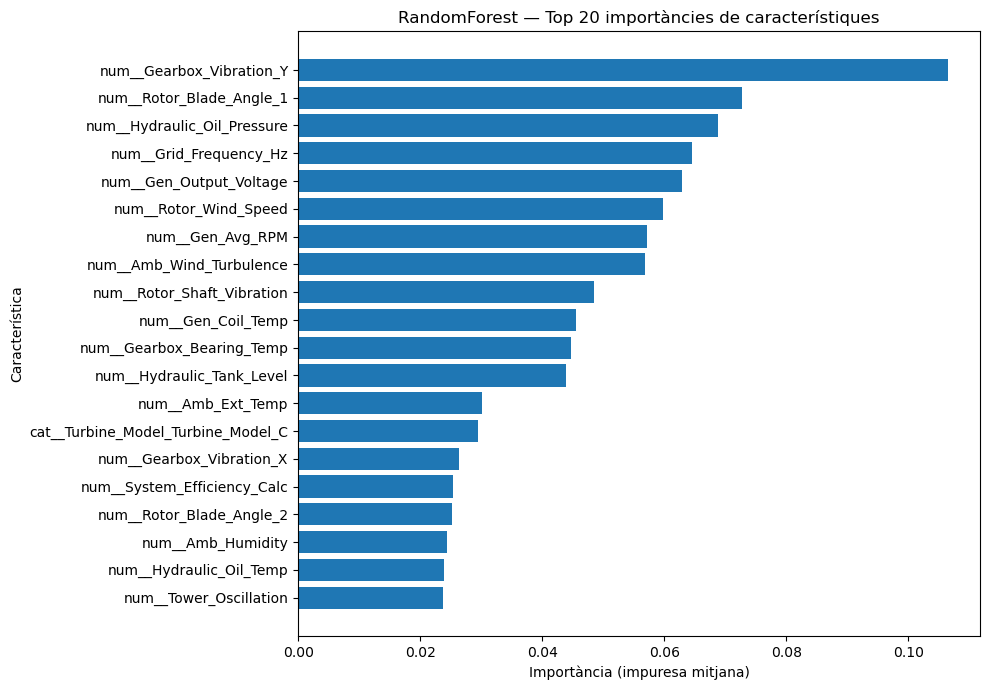

In [14]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Definim Train i Validació (segons el split que ja tenim)
# ------------------------------------------------------------
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ------------------------------------------------------------
# 2) Recuperem el millor model de la cerca
#    (GridSearchCV amb refit=True ja el deixa entrenat sobre tot X_tr)
# ------------------------------------------------------------
rf_best = search.best_estimator_  # Pipeline(preprocess + model)

print("Millors hiperparàmetres:", search.best_params_)
print("Millor score 5-CV (F1 macro):", search.best_score_)

# Per deixar-ho explícit, reentrenemt sobre tot el train:
rf_best.fit(X_tr, y_tr)

# ------------------------------------------------------------
# 3) Validació al conjunt de validació
# ------------------------------------------------------------
y_pred = rf_best.predict(X_val)

# probabilitats, útils més endavant per ensembles/plots
y_proba = rf_best.predict_proba(X_val)

acc = accuracy_score(y_val, y_pred)
bacc = balanced_accuracy_score(y_val, y_pred)
f1m = f1_score(y_val, y_pred, average="macro")
f1w = f1_score(y_val, y_pred, average="weighted")
cm = confusion_matrix(y_val, y_pred)

print("\n===== RandomForest (validació amb test) =====")
print(f"accuracy: {acc:.4f}")
print(f"balanced_accuracy: {bacc:.4f}")
print(f"f1_macro: {f1m:.4f}")
print(f"f1_weighted: {f1w:.4f}")
print("\nMatriu de confusió:\n", cm)
print("\nClassification report:\n", classification_report(y_val, y_pred, digits=4))

# Matriu de confusió normalitzada
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("\nMatriu de confusió normalitzada (per classe real):\n", np.round(cm_norm, 3))

# ------------------------------------------------------------
# 4) Importància de característiques (feature_importances_)
#    IMPORTANT: com que tenim One-Hot, les importàncies són per feature transformada.
# ------------------------------------------------------------
preprocess_fitted = rf_best.named_steps["preprocess"]
rf_model = rf_best.named_steps["model"]

feature_names = preprocess_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

display(fi.head(20))

# ------------------------------------------------------------
# 5) Gràfic Top-20 importàncies
# ------------------------------------------------------------
top_n = 20
fi_top = fi.head(top_n).iloc[::-1]  # invertim per pintar de menor a major a dalt/baix

plt.figure(figsize=(10, 7))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title(f"RandomForest — Top {top_n} importàncies de característiques")
plt.xlabel("Importància (impuresa mitjana)")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
<b>Validació del Random Forest final (Bagging) i importància de característiques</b><br><br>

<ul>
  <li><b>Millors hiperparàmetres (tuning amb 5-CV i F1 macro)</b><br>
    El procés de cerca (GridSearchCV amb 5 folds) selecciona la configuració:<br>
    <ul>
      <li><b>n_estimators = 1000</b></li>
      <li><b>max_depth = None</b></li>
      <li><b>max_features = 0.5</b></li>
    </ul>
    La millor puntuació mitjana de validació creuada obtinguda amb aquesta configuració és:<br>
    <b>F1 macro (5-CV) = 0.7487</b>
  </li>

  <li><b>Avaluació en el conjunt de validació (validació externa)</b><br>
    Amb el model final entrenat sobre tot el conjunt d’entrenament, en validació s’obté:<br>
    <ul>
      <li><b>accuracy = 0.7783</b></li>
      <li><b>balanced_accuracy = 0.7139</b></li>
      <li><b>F1 macro = 0.7294</b></li>
      <li><b>F1 weighted = 0.7663</b></li>
    </ul>
    Això suposa una millora respecte el millor model base (KNN) en la mètrica principal: <b>F1 macro</b> passa aproximadament de 0.702 a <b>0.729</b>, i també milloren accuracy i balanced accuracy.
  </li>

  <li><b>Millora en classes minoritàries? (matriu de confusió normalitzada)</b><br>
    Mirant el recall per classe (diagonal de la matriu normalitzada):<br>
    <ul>
      <li>Classe 0: <b>0.903</b> (rendiment molt alt, comparable al millor model base)</li>
      <li>Classe 1: <b>0.801</b> (millora clara respecte KNN, que tenia un recall més moderat en aquesta classe)</li>
      <li>Classe 2 (Failure): <b>0.438</b> (millora lleu respecte KNN, però continua sent la classe més difícil)</li>
    </ul>
    Per tant, el RF optimitzat aporta una millora global i també en la classe 1, mentre que la classe 2 continua sent el repte principal (encara hi ha una proporció rellevant de “2” que es prediuen com a “0” o “1”).
  </li>

  <li><b>Importància de característiques (feature_importances_)</b><br>
    Segons el gràfic i la taula de top importàncies, les variables més rellevants són:<br>
    <ul>
      <li><b>Gearbox_Vibration_Y</b> (la més important)</li>
      <li><b>Rotor_Blade_Angle_1</b></li>
      <li><b>Hydraulic_Oil_Pressure</b></li>
      <li><b>Grid_Frequency_Hz</b></li>
      <li><b>Gen_Output_Voltage</b></li>
      <li><b>Rotor_Wind_Speed</b> i <b>Gen_Avg_RPM</b></li>
      <li><b>Amb_Wind_Turbulence</b> i variables de vibració de l’eix (<b>Rotor_Shaft_Vibration</b>)</li>
    </ul>
    Aquest resultat és coherent amb un escenari de manteniment predictiu: vibracions (caixa de canvis / eix), angles de pala, pressió hidràulica i variables elèctriques (freqüència/voltge) aporten informació directa sobre estat mecànic i operatiu.<br>
    També es detecta com a rellevant una variable categòrica one-hot: <b>Turbine_Model_Turbine_Model_C</b>, cosa que indica que el model de turbina pot estar associat a diferències sistemàtiques en el comportament i/o la probabilitat d’alerta/fallada.
  </li>

  <li><b>Nota d’interpretació</b><br>
    Les importàncies mostrades són relatives i es poden repartir entre variables correlacionades (si dues variables expliquen el mateix patró, la importància es pot “dividir”). Això no invalida el rànquing, però recomana interpretar-lo com a indicació de rellevància, no com a causalitat.
  </li>
</ul>

</i></b></span>


## 4. Combinació paral·lela de classificadors de base similar: Boosting (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `GradientBoostingClassifier`.
2. Realitza una cerca i ajust (*tuning*) d'hiperparàmetres clau utilitzant validació creuada. Defineix un rang de cerca raonable per a cada hiperparàmetre i utilitza la mètrica F1 seleccionada.
3. Reporta els millors hiperparàmetres trobats i la puntuació (*score*) de validació creuada obtinguda amb ells.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Implementa GradientBoostingClassifier.
Realitza una cerca i ajust (tuning) d'hiperparàmetres clau utilitzant validació creuada. Defineix un rang de cerca raonable per a cada hiperparàmetre i utilitza la mètrica F1 seleccionada
</i></b></span>

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV

# ============================================================
# 1) Definim Train i Validació (seguint el criteri de la PAC)
#    - Entrenem i fem CV sobre X_train/y_train
#    - Reservem X_test/y_test com a validació externa (per després)
# ============================================================
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ============================================================
# 2) Pipeline: preprocessament + Gradient Boosting
#    - Amb Gradient Boosting (arbres), l'escalat no és crític,
#      però mantenim el mateix preprocessament per consistència
#      i perquè ens resol les variables categòriques (one-hot).
# ============================================================
gb = GradientBoostingClassifier(random_state=42)

gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", gb)
])

# ============================================================
# 3) Validació creuada estratificada (5-CV)
#    - Manté proporcions de classe similars a cada fold
# ============================================================
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4) Rang de cerca "raonable" (hiperparàmetres clau)
#    - n_estimators: nombre d'etapes (arbres) del boosting
#    - learning_rate: quant pesa cada etapa (trade-off amb n_estimators)
#    - max_depth: complexitat de cada arbre base (més profund -> més risc d'overfitting)
#    - subsample: <1.0 introdueix stochastic GB (més robustesa, menys variància)
#    - max_features: controla quantes variables considera cada split (diversitat)
# ============================================================
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__max_features": [None, "sqrt", 0.5]
}

# ============================================================
# 5) Cerca i ajust
#    - Optimitzem F1 macro (multiclasse, pes igual per classe)
#    - GradientBoosting és més lent que RF; si el grid és pesat,
#      podem canviar a RandomizedSearchCV.
# ============================================================
USE_RANDOMIZED = False  # posem True si volem menys precissió amb Randomized

if USE_RANDOMIZED:
    search_gb = RandomizedSearchCV(
        estimator=gb_pipe,
        param_distributions=param_grid,
        n_iter=40,              # combinacions aleatòries a provar
        scoring="f1_macro",
        cv=cv5,
        n_jobs=-1,
        verbose=2,
        random_state=42,
        return_train_score=True
    )
else:
    search_gb = GridSearchCV(
        estimator=gb_pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv5,
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

# Executem la cerca sobre el conjunt d'entrenament
search_gb.fit(X_tr, y_tr)

# ============================================================
# 6) Report: millors hiperparàmetres i score de CV
# ============================================================
print("\nMillors hiperparàmetres trobats (GradientBoosting):")
print(search_gb.best_params_)

print("\nMillor puntuació de validació creuada (F1 macro):")
print(search_gb.best_score_)

# ============================================================
# 7) Taula resum de les 10 millors combinacions
# ============================================================
cv_results = pd.DataFrame(search_gb.cv_results_)
cols = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "param_model__n_estimators", "param_model__learning_rate",
    "param_model__max_depth", "param_model__subsample", "param_model__max_features"
]
display(cv_results[cols].sort_values("rank_test_score").head(10))

# Guardem el millor model (ja refit sobre tot X_tr amb els millors hiperparàmetres)
gb_best = search_gb.best_estimator_


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Millors hiperparàmetres trobats (GradientBoosting):
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__max_features': None, 'model__n_estimators': 500, 'model__subsample': 0.8}

Millor puntuació de validació creuada (F1 macro):
0.7867750281872644


,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,param_model__max_features
126,1,0.786775,0.010159,500,0.1,4,0.8,None
198,2,0.784707,0.008883,500,0.2,4,0.8,None
214,3,0.784380,0.009108,500,0.2,4,0.8,0.5
212,4,0.783146,0.010057,300,0.2,4,0.8,0.5
206,5,0.782193,0.011825,500,0.2,4,0.8,sqrt
142,6,0.777506,0.010059,500,0.1,4,0.8,0.5
124,7,0.776946,0.007861,300,0.1,4,0.8,None
196,8,0.775478,0.007363,300,0.2,4,0.8,None
132,9,0.774319,0.009277,300,0.1,4,0.8,sqrt
134,10,0.773883,0.009665,500,0.1,4,0.8,sqrt


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Reporta els millors hiperparàmetres trobats i la puntuació (score) de validació creuada obtinguda amb ells.
</i></b></span>

<span style="color: purple;"><b><i>
<b>Boosting (GradientBoostingClassifier) — Tuning amb GridSearchCV i 5-CV</b><br><br>

<ul>
  <li><b>Configuració del procés</b><br>
    S’ha implementat <b>GradientBoostingClassifier</b> i s’ha ajustat amb <b>GridSearchCV</b> utilitzant <b>validació creuada estratificada de 5 folds</b>.<br>
    Com a mètrica d’optimització s’ha utilitzat <b>F1 macro</b>, ja que és la més informativa en un problema multiclasse amb desbalanceig moderat perquè dona el mateix pes a totes les classes.
  </li>

  <li><b>Rangs de cerca (hiperparàmetres clau)</b><br>
    S’han explorat combinacions raonables dels hiperparàmetres següents:<br>
    <ul>
      <li><i>n_estimators</i>: {100, 200, 300, 500}</li>
      <li><i>learning_rate</i>: {0.05, 0.1, 0.2}</li>
      <li><i>max_depth</i>: {2, 3, 4}</li>
      <li><i>subsample</i>: {0.8, 1.0}</li>
      <li><i>max_features</i>: {None, sqrt, 0.5}</li>
    </ul>
  </li>

  <li><b>Millors hiperparàmetres trobats (best_params_)</b><br>
    <ul>
      <li><b>n_estimators = 500</b></li>
      <li><b>learning_rate = 0.1</b></li>
      <li><b>max_depth = 4</b></li>
      <li><b>subsample = 0.8</b></li>
      <li><b>max_features = None</b></li>
    </ul>
  </li>

  <li><b>Puntuació de validació creuada amb els millors hiperparàmetres</b><br>
    La millor puntuació mitjana obtinguda en <b>5-CV</b> ha estat:<br>
    <b>F1 macro = 0.7868</b>
  </li>

  <li><b>Comentari breu del resultat</b><br>
    El valor <i>subsample = 0.8</i> introdueix estocasticitat en el boosting i acostuma a millorar la generalització reduint variància. La combinació de <i>n_estimators</i> alt (500) amb <i>learning_rate</i> moderat (0.1) suggereix un aprenentatge progressiu i estable, mentre que <i>max_depth = 4</i> permet capturar no-linealitats amb arbres base una mica més expressius.
  </li>
</ul>

</i></b></span>


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

4. Valida (amb el conjunt de dades de validació) el model final.
5. Mostra un gràfic de la importància de les característiques d'aquest model.
6. **Anàlisi Crítica:** Compara el rendiment del teu Gradient Boosting optimitzat amb els models anteriors. Ha aconseguit una millora substancial? Analitza el teu gràfic d'importància de característiques: Existeixen diferències notables en el rànquing o en les variables considerades més importants pels models de boosting en comparació amb Random Forest?
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
<b>Validació del Gradient Boosting final i importància de característiques</b><br><br>
<ul>
  <li>Amb els millors hiperparàmetres trobats per <b>GridSearchCV (5-CV)</b>, validem el model final sobre el conjunt de validació (<i>X_test, y_test</i>).</li>
  <li>Reportem les mateixes mètriques (especialment <b>F1 macro</b>) i mostrem la <b>matriu de confusió</b> (i opcionalment la normalitzada).</li>
  <li>Finalment, representem el gràfic de <b>feature_importances_</b> del model.</li>
</ul>
</i></b></span>


Millors hiperparàmetres: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__max_features': None, 'model__n_estimators': 500, 'model__subsample': 0.8}
Millor score 5-CV (F1 macro): 0.7867750281872644

===== GradientBoosting (validació) =====
accuracy: 0.8167
balanced_accuracy: 0.7756
f1_macro: 0.7856
f1_weighted: 0.8124

Matriu de confusió:
 [[265  24   9]
 [ 19 154   8]
 [ 28  22  71]]

Classification report:
               precision    recall  f1-score   support

           0     0.8494    0.8893    0.8689       298
           1     0.7700    0.8508    0.8084       181
           2     0.8068    0.5868    0.6794       121

    accuracy                         0.8167       600
   macro avg     0.8087    0.7756    0.7856       600
weighted avg     0.8168    0.8167    0.8124       600


Matriu de confusió normalitzada (per classe real):
 [[0.889 0.081 0.03 ]
 [0.105 0.851 0.044]
 [0.231 0.182 0.587]]


,feature,importance
0,num__Gearbox_Vibration_Y,0.116334
1,num__Hydraulic_Oil_Pressure,0.081285
2,num__Rotor_Blade_Angle_1,0.071983
3,num__Gen_Output_Voltage,0.071488
4,num__Gen_Avg_RPM,0.069954
5,num__Rotor_Wind_Speed,0.067452
6,num__Grid_Frequency_Hz,0.067242
7,num__Gen_Coil_Temp,0.062859
8,num__Amb_Wind_Turbulence,0.057439
9,num__Gearbox_Bearing_Temp,0.048676


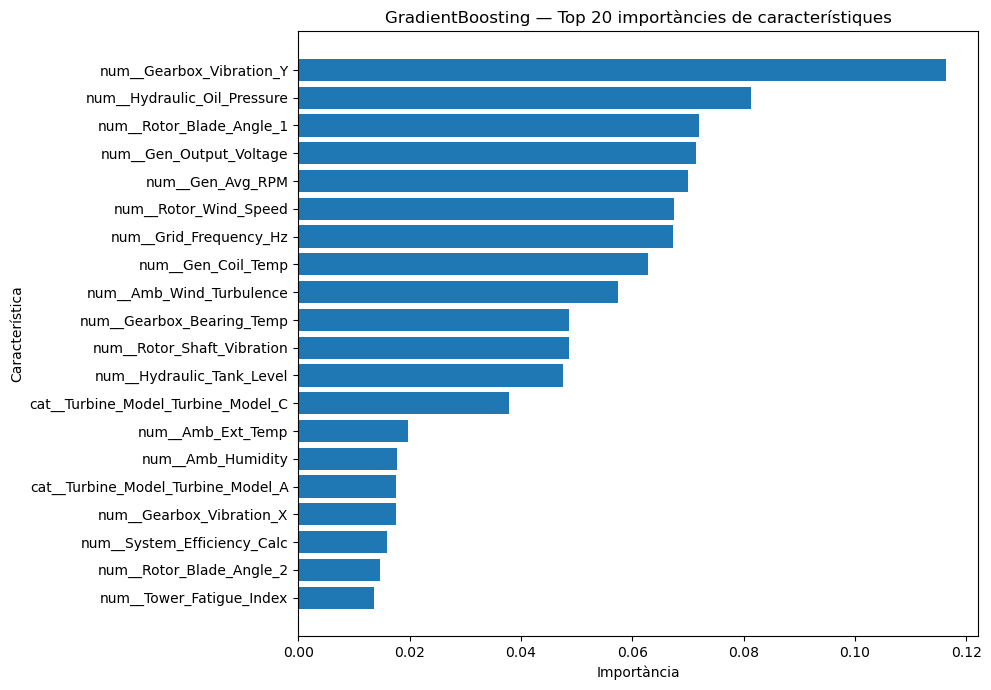

In [16]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Train i Validació (segons el split que ja fem servir a la PAC)
# ------------------------------------------------------------
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ------------------------------------------------------------
# 2) Recuperem el millor model del GridSearch de Gradient Boosting
#    (best_estimator_ ja queda "refit" sobre tot X_tr)
# ------------------------------------------------------------
gb_best = search_gb.best_estimator_   # Pipeline(preprocess + model)

print("Millors hiperparàmetres:", search_gb.best_params_)
print("Millor score 5-CV (F1 macro):", search_gb.best_score_)

# Reentrenem sobre tot el train
gb_best.fit(X_tr, y_tr)

# ------------------------------------------------------------
# 3) Validació a X_val / y_val
# ------------------------------------------------------------
y_pred = gb_best.predict(X_val)
y_proba = gb_best.predict_proba(X_val)

acc = accuracy_score(y_val, y_pred)
bacc = balanced_accuracy_score(y_val, y_pred)
f1m = f1_score(y_val, y_pred, average="macro")
f1w = f1_score(y_val, y_pred, average="weighted")
cm = confusion_matrix(y_val, y_pred)

print("\n===== GradientBoosting (validació) =====")
print(f"accuracy: {acc:.4f}")
print(f"balanced_accuracy: {bacc:.4f}")
print(f"f1_macro: {f1m:.4f}")
print(f"f1_weighted: {f1w:.4f}")
print("\nMatriu de confusió:\n", cm)
print("\nClassification report:\n", classification_report(y_val, y_pred, digits=4))

# Matriu normalitzada (recall per classe = diagonal)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("\nMatriu de confusió normalitzada (per classe real):\n", np.round(cm_norm, 3))

# ------------------------------------------------------------
# 4) Importància de característiques (feature_importances_)
#    Recordem: amb One-Hot, la importància és per feature transformada.
# ------------------------------------------------------------
preprocess_fitted = gb_best.named_steps["preprocess"]
gb_model = gb_best.named_steps["model"]

feature_names = preprocess_fitted.get_feature_names_out()
importances = gb_model.feature_importances_

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

display(fi.head(20))

# ------------------------------------------------------------
# 5) Gràfic Top-20 importàncies
# ------------------------------------------------------------
top_n = 20
fi_top = fi.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title(f"GradientBoosting — Top {top_n} importàncies de característiques")
plt.xlabel("Importància")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Anàlisi Crítica: Compara el rendiment del teu Gradient Boosting optimitzat amb els models anteriors. Ha aconseguit una millora substancial? Analitza el teu gràfic d'importància de característiques: Existeixen diferències notables en el rànquing o en les variables considerades més importants pels models de boosting en comparació amb Random Forest?
</i></b></span>

## Anàlisi crítica — Gradient Boosting optimitzat vs models anteriors

- **Millora de rendiment: és substancial?**  
  Sí, s’observa una **millora clara i substancial** respecte als models anteriors, especialment en la mètrica principal **F1 macro**.

  **Comparació (mètrica principal: F1 macro en validació)**  
  - Models base: el millor era **KNN** amb **F1 macro ≈ 0.702**.  
  - Bagging (Random Forest optimitzat): **F1 macro ≈ 0.729**.  
  - Boosting (Gradient Boosting optimitzat): **F1 macro = 0.7856**.  

  L’increment de **F1 macro** és d’aproximadament **+0.056** respecte Random Forest i **+0.084** respecte KNN, que és una millora rellevant en un problema multiclasse amb desbalanceig moderat.

  També milloren les altres mètriques globals: **accuracy = 0.8167** i **balanced_accuracy = 0.7756**, per sobre de Random Forest (accuracy ≈ 0.778 i balanced_accuracy ≈ 0.714).

- **Lectura per classe (matriu de confusió normalitzada)**  
  El boosting millora l’equilibri entre classes (diagonal = recall per classe):  
  - Classe 0: **0.889**  
  - Classe 1: **0.851**  
  - Classe 2 (Failure): **0.587**  

  El canvi més rellevant és la **classe 2**: el recall puja fins a **0.587**, millorant clarament els valors previs (Random Forest ≈ 0.438 i KNN ≈ 0.413). Això indica que el boosting detecta més *failures* i redueix els falsos negatius en la classe minoritària.

- **Importància de característiques: diferències vs Random Forest?**  
  En general, hi ha una **coincidència important** en el tipus de variables més rellevants, però també es veuen **canvis en el pes relatiu i l’ordre del rànquing**.

  **Similituds destacables**  
  Tant Random Forest com Gradient Boosting identifiquen com a variables clau:  
  - **Gearbox_Vibration_Y** (1a en ambdós models)  
  - **Rotor_Blade_Angle_1**  
  - **Hydraulic_Oil_Pressure**  
  - **Gen_Output_Voltage**, i variables operatives com **Grid_Frequency_Hz**, **Gen_Avg_RPM**, **Rotor_Wind_Speed**  
  - Variables ambientals com **Amb_Wind_Turbulence**  
  - Variables categòriques del model de turbina (one-hot) com **Turbine_Model** apareixen també entre les importants.

  **Diferències notables**  
  - En boosting, **Hydraulic_Oil_Pressure** puja fins a les primeres posicions (molt destacada).  
  - En Random Forest, **Grid_Frequency_Hz** apareixia especialment amunt en el rànquing; en boosting continua sent important però amb pes relativament inferior respecte pressió hidràulica i angles de pala.  
  - En boosting guanyen pes variables de generació i condicions (p. ex. **Gen_Avg_RPM** i **Gen_Coil_Temp**), mostrant un rànquing més concentrat en un conjunt reduït de variables amb importància alta.

  **Interpretació**  
  És esperable que hi hagi diferències: Random Forest (bagging) tendeix a repartir la importància entre variables correlacionades, mentre que Gradient Boosting (seqüencial) acostuma a focalitzar-se més en les variables que redueixen millor l’error a cada etapa. Això pot fer que algunes variables pugin o baixin posicions, mantenint un nucli comú de variables crítiques.



## 5. Combinació seqüencial de classificadors de base diferent: Stacking (1.5 punt)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `StackingClassifier`.
2. Utilitza els models base implementats a la secció 2. Creus que aquesta combinació de models és diversa i adequada per a Stacking?
3. Tria un metaclassificador. Pots optar per utilitzar els hiperparàmetres per defecte o realitzar un petit ajust si ho consideres necessari.
4. Valida l'`StackingClassifier` complet utilitzant les dades de validació amb la mètrica F1 seleccionada. Reporta la puntuació (*score*).
5. **Anàlisi Crítica:** Compara el rendiment del teu model de Stacking amb el millor resultat que vas obtenir d'un *ensemble* individual (RF o Boosting) en els passos anteriors. Va aportar l'Stacking una millora significativa del rendiment en aquest dataset? Explica breument com creus que el metaclassificador està utilitzant les prediccions dels teus *base learners* escollits.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Implementem StackingClassifier utilitzant els models base implementats a la secció 2:
</i></b></span>

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Definim Train i Validació (fem servir X_test/y_test com a validació externa)
# ------------------------------------------------------------
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ------------------------------------------------------------
# 2) Helper: convertim a dens per compatibilitat amb GaussianNB
#    (si l’entrada ja és densa, la deixem igual)
# Quan fem OneHotEncoder, el resultat sovint és una matriu sparse.
# Però GaussianNB (a scikit-learn) acostuma a requerir una entrada densa (un numpy array), no una matriu sparse.
# ------------------------------------------------------------
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    validate=False
)

# ------------------------------------------------------------
# 3) Reconstruïm els models base com a pipelines (preprocessament + model)
#    Això evita fuga de dades i manté el mateix tractament de variables.
# ------------------------------------------------------------
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipe_nb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("to_dense", to_dense),
    ("model", GaussianNB())
])

estimators = [
    ("logreg", pipe_lr),
    ("dtree", pipe_tree),
    ("knn", pipe_knn),
    ("gnb", pipe_nb)
]

# ------------------------------------------------------------
# 4) Metaclassificador (final_estimator)
#    Triem LogisticRegression per robustesa i perquè combina bé probabilitats.
# ------------------------------------------------------------
meta_clf = LogisticRegression(max_iter=2000, random_state=42)

# ------------------------------------------------------------
# 5) Stacking: fem servir CV estratificada per entrenar el meta-model
#    stack_method='predict_proba' fa servir probabilitats com a features del meta.
# ------------------------------------------------------------
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_clf,
    stack_method="predict_proba",
    cv=cv5,
    n_jobs=-1,
    passthrough=False
)

# ------------------------------------------------------------
# 6) Entrenem el stacking sobre tot el train
# ------------------------------------------------------------
stack_clf.fit(X_tr, y_tr)

# ------------------------------------------------------------
# 7) Validem al conjunt de validació externa
# ------------------------------------------------------------
y_pred = stack_clf.predict(X_val)
y_proba = stack_clf.predict_proba(X_val)

acc = accuracy_score(y_val, y_pred)
bacc = balanced_accuracy_score(y_val, y_pred)
f1m = f1_score(y_val, y_pred, average="macro")
f1w = f1_score(y_val, y_pred, average="weighted")
cm = confusion_matrix(y_val, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print("\n===== StackingClassifier (validació) =====")
print(f"accuracy: {acc:.4f}")
print(f"balanced_accuracy: {bacc:.4f}")
print(f"f1_macro: {f1m:.4f}")
print(f"f1_weighted: {f1w:.4f}")
print("\nMatriu de confusió:\n", cm)
print("\nMatriu de confusió normalitzada (per classe real):\n", np.round(cm_norm, 3))
print("\nClassification report:\n", classification_report(y_val, y_pred, digits=4))

# ------------------------------------------------------------
# 8) Guardem prediccions per a passos posteriors (si cal)
# ------------------------------------------------------------
stacking_predictions = {
    "y_val_pred": y_pred,
    "y_val_proba": y_proba,
    "confusion_matrix": cm,
    "confusion_matrix_norm": cm_norm,
    "metrics": {"accuracy": acc, "balanced_accuracy": bacc, "f1_macro": f1m, "f1_weighted": f1w}
}



===== StackingClassifier (validació) =====
accuracy: 0.7717
balanced_accuracy: 0.7131
f1_macro: 0.7233
f1_weighted: 0.7629

Matriu de confusió:
 [[265  20  13]
 [ 30 141  10]
 [ 33  31  57]]

Matriu de confusió normalitzada (per classe real):
 [[0.889 0.067 0.044]
 [0.166 0.779 0.055]
 [0.273 0.256 0.471]]

Classification report:
               precision    recall  f1-score   support

           0     0.8079    0.8893    0.8466       298
           1     0.7344    0.7790    0.7560       181
           2     0.7125    0.4711    0.5672       121

    accuracy                         0.7717       600
   macro avg     0.7516    0.7131    0.7233       600
weighted avg     0.7665    0.7717    0.7629       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Creus que aquesta combinació de models és diversa i adequada per a Stacking?
Tria un metaclassificador. Pots optar per utilitzar els hiperparàmetres per defecte o realitzar un petit ajust si ho consideres necessari.

<span style="color: purple;"><b><i>
Anàlisi Crítica: Compara el rendiment del teu model de Stacking amb el millor resultat que vas obtenir d'un ensemble individual (RF o Boosting) en els passos anteriors. Va aportar l'Stacking una millora significativa del rendiment en aquest dataset? Explica breument com creus que el metaclassificador està utilitzant les prediccions dels teus base learners escollits.
</i></b></span>

## Stacking — Diversitat dels models base i metaclassificador

### La combinació de models base és diversa i adequada?
Sí, perquè els quatre models base parteixen de supòsits i mecanismes d’aprenentatge diferents (biaixos inductius diferents), fet que acostuma a generar errors no totalment correlacionats:

- **Regressió logística**: separació lineal (robustesa, bona generalització si el problema és quasi lineal).
- **Arbre de decisió**: regles no lineals i interaccions (pot capturar patrons complexos, però és inestable si va sol).
- **KNN**: basat en distàncies i estructura local (no paramètric; funciona bé si hi ha clústers).
- **GaussianNB**: model probabilístic amb independència condicional (pot destacar en certes classes tot i ser simplificador).

Aquesta heterogeneïtat fa que el *stacking* tingui sentit: el metamodel pot aprendre quan “confiar” més en uns o altres.

### Metaclassificador triat
S’ha triat com a **metaclassificador una Regressió Logística** (amb paràmetres per defecte / lleuger ajust de `max_iter`, (`max_iter=2000`)) perquè:
- és un model **simple i estable**, amb menor risc de sobreajust com a meta-nivell,
- combina bé les sortides dels models base (especialment quan el *stacking* usa `predict_proba`),
- acostuma a funcionar bé com a “combinador” lineal de probabilitats.

### Rendiment del Stacking (validació)
En el conjunt de validació s’obté:
- **accuracy = 0.7717**
- **balanced_accuracy = 0.7131**
- **F1 macro = 0.7233** (mètrica principal)
- **F1 weighted = 0.7629**

Per classes (recall = diagonal de la matriu normalitzada):
- Classe 0: **0.889**
- Classe 1: **0.779**
- Classe 2 (Failure): **0.471**

Comparativament, el Stacking millora clarament alguns models base, però no supera els ensembles d’arbres optimitzats, especialment el **Gradient Boosting** (F1 macro = 0.7856), que també obté millor recall a la classe 2 (≈ 0.587). Això suggereix que els patrons que separen la classe 2 es beneficien més d’un enfocament boosting seqüencial amb arbres.


## 6. Combinació seqüencial de classificadors de base diferent: Cascading (1.5 punts)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Combina en cascada els models base implementats a la secció 2. Tingues en compte la definició presentada al document "Combinació de models - PID_00296757, Jordi Casas Roma i Julià Minguillón Alfonso" que es troba als recursos de l'assignatura. Explora un Stacking amb `passthrough=True`. Creus que aquesta combinació de models és diversa i adequada per a *Cascading*?
2. Tria un metaclassificador. Pots optar per utilitzar els hiperparàmetres per defecte o realitzar un petit ajust si ho consideres necessari.
3. Valida el teu classificador en cascada complet utilitzant les dades de validació amb la mètrica seleccionada. Reporta la puntuació (*score*).
4. **Anàlisi Crítica:** Compara el rendiment del teu model en cascada amb el millor resultat obtingut en els passos anteriors. Va aportar el *Cascading* una millora significativa del rendiment en aquest dataset? Has observat algun avantatge en termes d'eficiència computacional?
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Combina en cascada els models base implementats a la secció 2. Tingues en compte la definició presentada al document "Combinació de models - PID_00296757, Jordi Casas Roma i Julià Minguillón Alfonso" que es troba als recursos de l'assignatura. Explora un Stacking amb passthrough=True
</i></b></span>

## Per què entenem “Cascading = Stacking amb `passthrough=True`”?

A la pràctica, podem implementar una idea de **cascada (cascading)** fent servir `StackingClassifier` amb `passthrough=True`, perquè el flux d’informació queda “en cadena”: el model final rep tant les **sortides dels models previs** com les **dades originals**.

### Què fa `StackingClassifier` sense `passthrough`
1. Entrenem els **models base**.
2. A partir dels models base, generem **prediccions** (habitualment probabilitats si fem `stack_method="predict_proba"`).
3. El **metaclassificador** aprèn **només** a partir d’aquestes prediccions (com si fossin noves variables).

En aquest cas, el meta-model només veu “què diuen” els models base.

### Què canvia amb `passthrough=True`
Amb `passthrough=True`, el metaclassificador rep:
- les **prediccions / probabilitats** dels models base, i
- **+ les característiques originals** (`X`)

És a dir, l’entrada del metaclassificador és una concatenació del tipus:

`[predict_proba(model1), predict_proba(model2), ..., predict_proba(modelK), X_original]`

Això fa que el metaclassificador pugui **refinar** la decisió final combinant:
- el que han “deduït” els models base, i
- la informació original per corregir casos difícils.

### Per què això s’assembla a una cascada (cascading)
En una cascada, un model posterior utilitza:
- les **sortides** dels models anteriors,
- i sovint també les **dades originals**,
per prendre una decisió final més informada.

`passthrough=True` reprodueix aquesta idea perquè el metaclassificador no decideix només amb prediccions: també pot “mirar” les variables originals.

### Per què fem servir `stack_method="predict_proba"`
Amb `predict_proba`, el meta-model rep **probabilitats per classe**, no només la classe final. Això és útil perquè:
- pot capturar el **grau d’incertesa** (p. ex. 0.34 / 0.33 / 0.33),
- i pot aprendre millor quan un model base és fiable o no.

**Resum:** s’entén “Cascading = Stacking amb `passthrough=True`” perquè el model final combina informació en seqüència (prediccions dels models base + dades originals), que és l’essència del cascading.


In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score

# ------------------------------------------------------------
# 1) Definim Train i Validació 
# ------------------------------------------------------------
X_tr_prep, y_tr = X_train_prep, y_train
X_val_prep, y_val = X_test_prep, y_test   # <-- aquí fem servir "test" com a validació externa

# ------------------------------------------------------------
# 2) Helper: convertim a dens per a GaussianNB si cal
# Quan fem OneHotEncoder, el resultat sovint és una matriu sparse.
# Però GaussianNB (a scikit-learn) acostuma a requerir una entrada densa (un numpy array), no una matriu sparse.
# ------------------------------------------------------------
to_dense = FunctionTransformer(
    lambda X: X.toarray() if hasattr(X, "toarray") else X,
    validate=False
)

# ------------------------------------------------------------
# 3) Models base (els de la secció 2)
# ------------------------------------------------------------
estimators = [
    ("logreg", LogisticRegression(max_iter=2000, random_state=42)),
    ("dtree", DecisionTreeClassifier(random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
    ("gnb", Pipeline([("to_dense", to_dense), ("model", GaussianNB())])),
]

# ------------------------------------------------------------
# 4) Metaclassificador (robust i simple)
# ------------------------------------------------------------
meta_clf = LogisticRegression(max_iter=2000, random_state=42)

# ------------------------------------------------------------
# 5) Cascading = Stacking amb passthrough=True
# ------------------------------------------------------------
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cascading_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_clf,
    stack_method="predict_proba",
    cv=cv5,
    passthrough=True,
    n_jobs=-1
)

# ------------------------------------------------------------
# 6) Entrenem amb train i validem amb "validació externa"
# ------------------------------------------------------------
cascading_clf.fit(X_tr_prep, y_tr)
y_pred = cascading_clf.predict(X_val_prep)

# Mètrica principal
f1m = f1_score(y_val, y_pred, average="macro")
acc = accuracy_score(y_val, y_pred)
bacc = balanced_accuracy_score(y_val, y_pred)

print("\n===== Cascading (Stacking passthrough=True) - validació =====")
print(f"accuracy: {acc:.4f}")
print(f"balanced_accuracy: {bacc:.4f}")
print(f"f1_macro: {f1m:.4f}")

print("\nClassification report:\n", classification_report(y_val, y_pred, digits=4))

cm = confusion_matrix(y_val, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("\nMatriu de confusió normalitzada (per classe real):\n", np.round(cm_norm, 3))



===== Cascading (Stacking passthrough=True) - validació =====
accuracy: 0.7867
balanced_accuracy: 0.7348
f1_macro: 0.7455

Classification report:
               precision    recall  f1-score   support

           0     0.8168    0.8826    0.8484       298
           1     0.7475    0.8177    0.7810       181
           2     0.7625    0.5041    0.6070       121

    accuracy                         0.7867       600
   macro avg     0.7756    0.7348    0.7455       600
weighted avg     0.7849    0.7867    0.7794       600


Matriu de confusió normalitzada (per classe real):
 [[0.883 0.077 0.04 ]
 [0.144 0.818 0.039]
 [0.273 0.223 0.504]]


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Anàlisi Crítica: Compara el rendiment del teu model en cascada amb el millor resultat obtingut en els passos anteriors. Va aportar el Cascading una millora significativa del rendiment en aquest dataset? Has observat algun avantatge en termes d'eficiència computacional?
</i></b></span>

### Comparació de rendiment (mètrica principal: F1 macro)
El classificador en cascada (Stacking amb `passthrough=True`) obté en validació:

- **accuracy = 0.7867**
- **balanced_accuracy = 0.7348**
- **F1 macro = 0.7455**

Si ho comparem amb els millors resultats previs:
- **Gradient Boosting optimitzat**: **F1 macro = 0.7856** (millor resultat global fins ara)
- **Random Forest optimitzat**: **F1 macro ≈ 0.7294**
- **Stacking (sense passthrough)**: **F1 macro ≈ 0.7233**

Per tant, el **Cascading sí millora** respecte Stacking sense passthrough i respecte Random Forest, però **no supera** el millor model (Gradient Boosting). Això implica que **no aporta una millora significativa** del rendiment final en aquest dataset si el criteri és batre el millor resultat anterior.

### Lectura per classe (matriu de confusió normalitzada)
Els recalls (diagonal) del Cascading són:
- Classe 0: **0.883**
- Classe 1: **0.818**
- Classe 2 (Failure): **0.504**

Això mostra un comportament raonable en la classe minoritària (classe 2), però continua quedant per sota del Gradient Boosting, que havia aconseguit un recall de la classe 2 més alt (≈ 0.587). És a dir, el Cascading millora la combinació respecte a alguns models, però no aconsegueix el mateix nivell de detecció de “failures” que el boosting seqüencial.

### Eficiència computacional: hi ha avantatge?
No s’observa cap avantatge clar en eficiència computacional. De fet, el Cascading acostuma a ser **més costós** perquè:
- cal entrenar **tots** els models base,
- i a més entrenar el metaclassificador utilitzant prediccions generades amb **CV interna** (per evitar “leakage”),
- i amb `passthrough=True` el meta-model treballa amb més features (prediccions + dades originals).

En canvi, Gradient Boosting és un únic model (tot i que també pot ser exigent), però evita l’overhead d’entrenar múltiples models diferents i coordinar-los.

**Conclusió:** el Cascading no aporta una millora significativa respecte el millor resultat (Gradient Boosting) i tampoc sembla oferir un benefici d’eficiència; la seva utilitat aquí és sobretot metodològica (provar una combinació seqüencial de models heterogenis), però el millor compromís rendiment/complexitat en aquest dataset continua sent el Gradient Boosting optimitzat.


## 7. Alternativa: Balanced Random Forest (1 punt)

El BalancedRandomForestClassifier és una variant de l'algorisme d'ensamblatge Random Forest dissenyada específicament per abordar problemes de classificació amb classes severament desequilibrades sense necessitat de preprocessament extern (com SMOTE).

Mecanisme de Funcionament: La diferència fonamental respecte al Random Forest estàndard resideix en l'etapa de construcció de cada arbre de decisió individual (procés de bootstrapping):

Submostreig Dinàmic: Per entrenar cada arbre del bosc, l'algorisme genera un subconjunt de dades temporal. En aquest pas, realitza un submostreig aleatori (random undersampling) de la classe majoritària per igualar el nombre d'instàncies de la classe minoritària.

Entrenament Equilibrat: Com a resultat, cada arbre individual s'entrena amb un dataset perfectament balancejat (ràtio 1:1), tot i que el dataset original estigui descompensat.

Agregació: Finalment, el model combina les prediccions de tots els arbres (que han vist diferents subconjunts equilibrats de la classe majoritària) mitjançant votació per generar la predicció final.

Avantatge Principal: Permet aprofitar la robustesa del bagging (reducció de variància) mentre mitiga el biaix cap a la classe majoritària de forma nativa, explorant una major varietat de dades de la classe majoritària a través dels múltiples arbres.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

1. Implementa `BalancedRandomForestClassifier` de la llibreria `imblearn`.
2. Entrena i valida el classificador complet utilitzant la mètrica seleccionada. Reporta la puntuació (*score*).
5. **Anàlisi Crítica:** Compara el rendiment d'aquest model amb els anteriors. Diries que aquest model és més "intel·ligent" o simplement més "agressiu" disparant alarmes?
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Implementa BalancedRandomForestClassifier de la llibreria imblearn.
Entrena i valida el classificador complet utilitzant la mètrica seleccionada. Reporta la puntuació (score).
</i></b></span>

In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Definim train i validació (mateix criteri que la resta de la PAC)
# ------------------------------------------------------------
X_tr, y_tr = X_train, y_train
X_val, y_val = X_test, y_test

# ------------------------------------------------------------
# 2) Definim Balanced Random Forest
#    - Reutilitzem hiperparàmetres raonables (similars al RF optimitzat)
#    - La diferència clau és que BRF balanceja internament cada arbre via undersampling
# ------------------------------------------------------------
brf = BalancedRandomForestClassifier(
    n_estimators=1000,     # nombre d'arbres
    max_depth=None,        # profunditat (None = sense límit)
    max_features=0.5,      # proporció de variables candidates per split
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3) Pipeline: preprocessament + model
#    - Mantenim el mateix preprocessament (one-hot + numèriques) per coherència
# ------------------------------------------------------------
brf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", brf)
])

# ------------------------------------------------------------
# 4) Entrenem i validem
# ------------------------------------------------------------
brf_pipe.fit(X_tr, y_tr)
y_pred = brf_pipe.predict(X_val)

# Mètriques globals
acc = accuracy_score(y_val, y_pred)
bacc = balanced_accuracy_score(y_val, y_pred)
f1m = f1_score(y_val, y_pred, average="macro")       # mètrica principal
f1w = f1_score(y_val, y_pred, average="weighted")

print("\n===== BalancedRandomForest (validació) =====")
print(f"accuracy: {acc:.4f}")
print(f"balanced_accuracy: {bacc:.4f}")
print(f"f1_macro (score): {f1m:.4f}")
print(f"f1_weighted: {f1w:.4f}")

# Report i matrius de confusió
print("\nClassification report:\n", classification_report(y_val, y_pred, digits=4))

cm = confusion_matrix(y_val, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print("\nMatriu de confusió:\n", cm)
print("\nMatriu de confusió normalitzada (per classe real):\n", np.round(cm_norm, 3))

# (Opcional) Guardem prediccions per comparar més endavant
# preds_val["BalancedRF"] = y_pred


C:\Users\comum\.conda\envs\environment_uoc20251pec4_V2\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\comum\.conda\envs\environment_uoc20251pec4_V2\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\comum\.conda\envs\environment_uoc20251pec4_V2\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set


===== BalancedRandomForest (validació) =====
accuracy: 0.7833
balanced_accuracy: 0.7680
f1_macro (score): 0.7604
f1_weighted: 0.7843

Classification report:
               precision    recall  f1-score   support

           0     0.8676    0.7919    0.8281       298
           1     0.7549    0.8508    0.8000       181
           2     0.6452    0.6612    0.6531       121

    accuracy                         0.7833       600
   macro avg     0.7559    0.7680    0.7604       600
weighted avg     0.7888    0.7833    0.7843       600


Matriu de confusió:
 [[236  29  33]
 [ 16 154  11]
 [ 20  21  80]]

Matriu de confusió normalitzada (per classe real):
 [[0.792 0.097 0.111]
 [0.088 0.851 0.061]
 [0.165 0.174 0.661]]


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

<span style="color: purple;"><b><i>
Anàlisi Crítica: Compara el rendiment d'aquest model amb els anteriors. Diries que aquest model és més "intel·ligent" o simplement més "agressiu" disparant alarmes?
</i></b></span>

### Rendiment global (mètrica principal: F1 macro)
El **BalancedRandomForestClassifier** en validació obté:
- **accuracy = 0.7833**
- **balanced_accuracy = 0.7680**
- **F1 macro = 0.7604** *(score seleccionat)*
- **F1 weighted = 0.7843**

Comparant amb els millors resultats anteriors:
- **Gradient Boosting optimitzat**: **F1 macro = 0.7856** *(millor global)*
- **Cascading (Stacking passthrough=True)**: **F1 macro = 0.7455**
- **Random Forest optimitzat**: **F1 macro = 0.7294**
- **Stacking (sense passthrough)**: **F1 macro = 0.7233**
- Millor model base (KNN): **F1 macro ≈ 0.702**

Això indica que el **Balanced RF millora clarament** respecte Random Forest “estàndard” optimitzat i també supera el Cascading, però **no arriba** al nivell del Gradient Boosting, que continua sent el millor model del dataset.

### Lectura per classe (matriu de confusió normalitzada)
Els recalls per classe (diagonal de la matriu normalitzada) són:
- Classe 0: **0.792**
- Classe 1: **0.851**
- Classe 2 (Failure): **0.661**

El punt més rellevant és la **classe 2 (Failure)**: el Balanced RF aconsegueix un **recall = 0.661**, que és:
- superior al Cascading (**0.504**),
- superior al Random Forest optimitzat (**0.438**),
- i també superior al Gradient Boosting (**0.587**).

Per tant, tot i que el Gradient Boosting té millor **F1 macro** global, el Balanced RF destaca específicament en **detecció de falles** (classe 2), reduint falsos negatius en la classe minoritària.

### Interpretació i implicació pràctica
El comportament és coherent amb el mecanisme del Balanced RF: cada arbre s’entrena amb un subconjunt **equilibrat** (undersampling de la classe majoritària), cosa que redueix el biaix cap a la classe 0 i afavoreix recuperar més instàncies de la classe minoritària.

En un context operatiu, si la prioritat és **detectar falles** (classe 2) encara que això impliqui acceptar algun compromís en el rendiment global, el **Balanced RF és una alternativa molt competitiva**. Si l’objectiu és maximitzar el rendiment global equilibrat entre classes (F1 macro), el **Gradient Boosting** continua sent la millor elecció.

## Anàlisi crítica — Balanced Random Forest: “més intel·ligent” o més “agressiu”?


### Què passa amb la classe crítica (Failure)?
On realment destaca és en la **classe 2 (Failure)**:
- El **recall** de la classe 2 és **0.661**, superior a:
  - Gradient Boosting (≈ 0.587),
  - Cascading (≈ 0.504),
  - Random Forest (≈ 0.438).

Això vol dir que detecta **més falles reals** (menys falsos negatius), que en molts contextos és el més important.

### És més “intel·ligent” o més “agressiu”?
Diria que és sobretot **més “agressiu” disparant alarmes**, i aquesta “agressivitat” ve del seu disseny:
- En equilibrar internament el train de cada arbre (undersampling de la classe majoritària), el model queda **menys conservador** amb la classe 2 i tendeix a predir-la amb més facilitat.

Això no és necessàriament dolent: és una estratègia **intencionada** per corregir el biaix cap a la classe majoritària.

La prova que no és només “agressiu sense control” és que el seu **precision** per a la classe 2 no és baix: **precision ≈ 0.645**.  
És a dir, quan diu “Failure”, una proporció considerable de vegades encerta, però el guany gran és que **en deixa escapar menys** (recall alt).

### Conclusió
- Si la prioritat és **detectar tantes falles com sigui possible** (minimitzar falsos negatius), el Balanced RF és molt adequat i “més agressiu” és precisament el que interessa.
- Si la prioritat és maximitzar el rendiment global equilibrat (F1 macro) i mantenir una política d’alarma més “conservadora”, el **Gradient Boosting** continua sent el millor model global en aquest dataset.



## 8. Ajustament del Llindar de Decisió (1 punt)



<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementació:</h4>

Si tenim en compte que el trencament d'una turbina equival a una pèrdua de 50.000€ i que el cost d'inspecció de la turbina és de 200€, és preferible que el sistema activi alarmes encara que algunes siguin falses a que ignori fallades reals. Per defecte, un classificador decideix que alguna cosa és una "Fallada" si la probabilitat calculada és major que el 50%. Què passa si baixem aquesta exigència?

Amb ajuda de qualsevol model d'IA generativa, prioritza dràsticament la seguretat (Recall). El teu objectiu concret és ajustar la lògica de decisió del model per assolir un Recall mínim del 80% en la Classe 2 (Fallada Crítica).

Hauràs de demanar-li a la IA que t'expliqui com manipular el llindar de decisió (threshold) a partir de les probabilitats predites per aconseguir aquest objectiu sense modificar el model ni reentrenar-lo. Genera el nou informe de classificació i analitza: A quin preu (en termes de Precisió) has aconseguit aquesta seguretat?
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solució:</h4>
</div>

<span style="color: purple;"><b><i>
Si tenim en compte que el trencament d'una turbina equival a una pèrdua de 50.000€ i que el cost d'inspecció de la turbina és de 200€, és preferible que el sistema activi alarmes encara que algunes siguin falses a que ignori fallades reals. Per defecte, un classificador decideix que alguna cosa és una "Fallada" si la probabilitat calculada és major que el 50%. Què passa si baixem aquesta exigència?
</i></b></span>

## Ajustament del llindar de decisió (classe 2 = *Failure*) — raonament

En aquest problema, el cost de **no detectar una fallada real** és molt elevat (**50.000 €**), mentre que el cost de **fer una inspecció** quan salta una alarma és relativament baix (**200 €**). Per tant, és preferible activar alarmes encara que algunes siguin falses, abans que ignorar fallades reals.

### Per què canviar el llindar?
Per defecte, moltes decisions es prenen amb un criteri “estàndard” (p. ex. considerar *Failure* només si la probabilitat és molt alta). Si **baixem el llindar** necessari per predir *Failure*, el sistema serà més sensible:
- augmentarà la detecció de fallades reals (**puja el recall** de la classe 2),
- però també augmentaran les alarmes falses (**baixa la precisió** de la classe 2).

Aquesta és una compensació típica: **menys falsos negatius** a canvi de **més falsos positius**.

### Criteri basat en costos (quan convé activar alarma)
Si interpretem “activar alarma” com “fer inspecció”, tenim dues opcions:
- **Alarmar** ⇒ cost fix de **200 €**
- **No alarmar** ⇒ si realment era fallada, cost de **50.000 €**

Si el model assigna una probabilitat $p$ a la classe *Failure*, el cost esperat de **no alarmar** és:

$$
\text{Cost(no alarmar)} = p \cdot 50{,}000
$$

I el cost d’**alarmar** (fer inspecció) és:

$$
\text{Cost(alarmar)} = 200
$$

Convindrà alarmar quan:

$$
200 < p \cdot 50{,}000
\;\;\Rightarrow\;\;
p > \frac{200}{50{,}000}
=
0.004
$$


Això significa que, amb aquests costos, ja és raonable activar una alarma si la probabilitat de fallada supera només el **0,4%**, un llindar molt inferior al 50%.

### Què s’espera que passi si baixem la “exigència”?
En reduir el llindar per predir *Failure*:
- **baixen els falsos negatius (FN)** de la classe 2 (es perden menys fallades),
- **pugen els falsos positius (FP)** (més alarmes falses),
- i el rendiment global (accuracy) pot baixar, però el sistema pot ser **millor operativament** segons el cost total.

Com que el cost d’un FN és equivalent a pagar **250 inspeccions**:

$$
\frac{50{,}000}{200} = 250
$$

evitar una sola fallada no detectada compensa moltes alarmes falses.


### Conclusió
Ajustar el llindar té sentit perquè l’objectiu no és només maximitzar mètriques globals, sinó **minimitzar el cost esperat**. Amb els costos donats, és coherent utilitzar un llindar molt més baix per a *Failure* per reduir al màxim els falsos negatius.


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# -----------------------------
# CONFIG
# -----------------------------
COST_BREAKDOWN = 50000   # € si s'ignora una fallada real (FN de classe 2)
COST_INSPECTION = 200    # € per alarma (inspecció)

# Tria el model ja entrenat que vols avaluar:
# - gb_best  (Gradient Boosting optimitzat, Pipeline)
# - brf_pipe (BalancedRandomForest, Pipeline)
# - o qualsevol altre Pipeline que tinguem
model = gb_best   # <-- canviem a brf_pipe si volem

X_val, y_val = X_test, y_test  # validació externa

# Obtenim probabilitats per classe
proba = model.predict_proba(X_val)
classes = model.classes_
idx2 = list(classes).index(2)  # columna de la classe "Fallada" (2)

p2 = proba[:, idx2]

def predict_with_failure_threshold(proba, classes, t=0.5, failure_class=2):
    """Si P(failure)>=t => prediu failure; si no => argmax entre la resta."""
    classes = list(classes)
    idx_fail = classes.index(failure_class)

    preds = []
    for row in proba:
        if row[idx_fail] >= t:
            preds.append(failure_class)
        else:
            row2 = row.copy()
            row2[idx_fail] = -np.inf  # excloem la classe 2 quan no supera llindar
            preds.append(classes[int(np.argmax(row2))])
    return np.array(preds)

def eval_threshold(t):
    y_pred_t = predict_with_failure_threshold(proba, classes, t=t, failure_class=2)

    # mètrica principal (macro)
    f1m = f1_score(y_val, y_pred_t, average="macro")

    # mètriques específiques de "alarmar fallada"
    alarms = np.sum(y_pred_t == 2)
    true_fail = np.sum(y_val == 2)

    fn = np.sum((y_val == 2) & (y_pred_t != 2))  # fallades no detectades
    fp = np.sum((y_val != 2) & (y_pred_t == 2))  # alarmes falses

    # cost esperat a la validació
    cost = alarms * COST_INSPECTION + fn * COST_BREAKDOWN

    return {
        "threshold": t,
        "F1_macro": f1m,
        "alarms_total": alarms,
        "false_alarms_FP": fp,
        "missed_failures_FN": fn,
        "true_failures": true_fail,
        "cost_euros": cost
    }

# Prova un conjunt de llindars (inclòs el derivat per cost: 0.004)
thresholds = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.004, 0.002]

rows = [eval_threshold(t) for t in thresholds]
df_thr = pd.DataFrame(rows).sort_values("threshold", ascending=False)

display(df_thr)

# Si vols veure el detall del millor llindar segons cost:
best_by_cost = df_thr.sort_values("cost_euros").iloc[0]
print("\nMillor llindar per COST (validació):")
print(best_by_cost)

t_best = float(best_by_cost["threshold"])
y_pred_best = predict_with_failure_threshold(proba, classes, t=t_best, failure_class=2)

print("\nClassification report (t millor per cost):\n",
      classification_report(y_val, y_pred_best, digits=4))

cm = confusion_matrix(y_val, y_pred_best)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("\nMatriu confusió normalitzada (t millor per cost):\n", np.round(cm_norm, 3))


,threshold,F1_macro,alarms_total,false_alarms_FP,missed_failures_FN,true_failures,cost_euros
0,0.500,0.781668,82,14,53,121,2666400
1,0.300,0.786693,104,26,43,121,2170800
2,0.200,0.774616,127,43,37,121,1875400
3,0.100,0.765509,162,67,26,121,1332400
4,0.050,0.745519,202,99,18,121,940400
5,0.020,0.687890,267,156,10,121,553400
6,0.010,0.644328,310,194,5,121,312000
7,0.005,0.568673,367,248,2,121,173400
8,0.004,0.546476,381,262,2,121,176200
9,0.002,0.477175,428,308,1,121,135600



Millor llindar per COST (validació):
threshold                  0.002000
F1_macro                   0.477175
alarms_total             428.000000
false_alarms_FP          308.000000
missed_failures_FN         1.000000
true_failures            121.000000
cost_euros            135600.000000
Name: 9, dtype: float64

Classification report (t millor per cost):
               precision    recall  f1-score   support

           0     0.9904    0.3456    0.5124       298
           1     0.8824    0.3315    0.4819       181
           2     0.2804    0.9917    0.4372       121

    accuracy                         0.4717       600
   macro avg     0.7177    0.5563    0.4772       600
weighted avg     0.8146    0.4717    0.4881       600


Matriu confusió normalitzada (t millor per cost):
 [[0.346 0.023 0.631]
 [0.006 0.331 0.663]
 [0.    0.008 0.992]]


## Resultats de l’ajustament del llindar (classe 2 = *Failure*) i interpretació (amb criteri de cost)

### Criteri basat en costos (quan convé alarmar)
Si el model assigna una probabilitat $p$ a la classe *Failure*, el cost esperat de **no alarmar** és:

$$
\text{Cost(no alarmar)} = p \cdot 50000
$$

I el cost d’**alarmar** (fer inspecció) és:

$$
\text{Cost(alarmar)} = 200
$$

Convindrà alarmar quan:

$$
200 < p \cdot 50000
\;\;\Rightarrow\;\;
p > \frac{200}{50000}
=
0.004
$$

Això vol dir que ja és raonable activar una alarma si la probabilitat de fallada supera el **0.4%**.

Com que el cost d’un FN és equivalent a pagar **250 inspeccions**:

$$
\frac{50000}{200} = 250
$$

evitar una sola fallada no detectada compensa moltes alarmes falses.

---

Tot i que el llindar teòric derivat dels costos és **0.004**, la cerca empírica sobre el conjunt de validació mostra que el mínim de cost s’assoleix amb **t = 0.002** **(threshold)**, perquè reduir un **FN** addicional (estalvi de 50.000 €) compensa de sobres l’increment d’inspeccions (cost de 200 € cadascuna).


### Comparació de cost: llindar “exigent” vs llindar òptim per cost (validació)

**Amb $t = 0.5$:**
- Alarmes totals: **82**
- FN (fallades no detectades): **53**
- Cost total:

$$
82 \cdot 200 + 53 \cdot 50000 = 2666400
$$

Cost total: **2.666.400 €**

**Amb $t = 0.002$ (millor per cost en validació):**
- Alarmes totals: **428**
- FN: **1**
- Cost total:

$$
428 \cdot 200 + 1 \cdot 50000 = 135600
$$

Cost total: **135.600 €**


<span style="color: purple;"><b><i>
Amb ajuda de qualsevol model d'IA generativa, prioritza dràsticament la seguretat (Recall). El teu objectiu concret és ajustar la lògica de decisió del model per assolir un Recall mínim del 80% en la Classe 2 (Fallada Crítica).

<span style="color: purple;"><b><i>
Hauràs de demanar-li a la IA que t'expliqui com manipular el llindar de decisió (threshold) a partir de les probabilitats predites per aconseguir aquest objectiu sense modificar el model ni reentrenar-lo. Genera el nou informe de classificació i analitza: A quin preu (en termes de Precisió) has aconseguit aquesta seguretat?
</i></b></span>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Anàlisi:</h4>  
    
**UTILITZA TANTES CEL·LES COM EN NECESSITIS**
</div>

## Priorització de seguretat: ajustar el llindar per assolir Recall >= 0.80 a la classe 2 (Fallada crítica)

### Què s’ha fet (sense reentrenar el model)
S’ha utilitzat una IA generativa (ChatGPT) per entendre com **modificar la lògica de decisió** a partir de `predict_proba()` per forçar una detecció més segura de la classe 2 (*Failure*), **sense canviar ni reentrenar el model**.

La idea és tractar la classe 2 com una **alarma one-vs-rest**:

La regla de decisió aplicada és:
- Si $P(\mathrm{Failure}) < t$ ⇒ $\hat{y} = \arg\max_{c \in \{0,1\}} P(c)$


En baixar el llindar \(t\), augmenta el **Recall** (es perden menys fallades), però empitjora la **Precisió** (més alarmes falses).

---

### Com es tria el llindar per garantir Recall >= 0.80
A partir de la taula d’experiments de llindars, s’observa que:
- amb \(t = 0.10\) el recall de la classe 2 és aproximadament \(0.785\) (insuficient)
- amb \(t = 0.05\) el recall puja fins a aproximadament \(0.851\) (objectiu complert)

Per tant, **\(t = 0.05\)** és el primer llindar provat que assegura **Recall >= 0.80**.

Per a la classe 2 (*Failure*), definim:

- **TP** (*True Positives*): casos reals de classe 2 predits com a 2  
- **FP** (*False Positives*): casos NO-2 predits com a 2 (alarmes falses)  
- **FN** (*False Negatives*): casos reals de classe 2 predits com a NO-2 (fallades perdudes)

Si “alarmes totals” vol dir **nombre de prediccions com a classe 2**, aleshores:

$$
\text{Alarmes totals} = TP + FP
$$

i, per tant:

$$
TP = \text{Alarmes totals} - FP
$$

Les mètriques són:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
\text{Precisió} = \frac{TP}{TP + FP}
$$

Amb \(t = 0.05\) (dades de validació):
- Alarmes totals = 202, FP = 99  =>  \(TP = 103\)
- FN = 18  (sobre 121 fallades reals)

Així:
- Recall classe 2:

  $$
  \frac{103}{103+18} \approx 0.851
  $$

- Precisió classe 2:

  $$
  \frac{103}{103+99} \approx 0.510
  $$


---

## Nou informe de classificació (per llindar t = 0.05)

> Executant el mateix codi d’avaluació amb \(t=0.05\) es genera el `classification_report` complet.  
> A continuació s’analitza el “preu” pagat en precisió per assolir el recall objectiu.

### A quin preu (en precisió) s’aconsegueix aquesta seguretat?
Comparant amb el llindar exigent \(t = 0.5\):

**Amb \(t = 0.5\)**:
- TP = 68, FP = 14, FN = 53
- **Precisió classe 2 ≈ 0.829**
- **Recall classe 2 ≈ 0.562** (no compleix)

**Amb \(t = 0.05\)** (objectiu complert):
- TP = 103, FP = 99, FN = 18
- **Precisió classe 2 ≈ 0.510**
- **Recall classe 2 ≈ 0.851**

**Conclusió:** per pujar el recall de ~0.56 a ~0.85, la precisió cau de ~0.83 a ~0.51. En termes operatius, això vol dir que:
- es detecten moltes més fallades reals (més seguretat),
- però aproximadament **la meitat** de les alarmes seran falses (més inspeccions innecessàries).

---

### Codi recomanat (automatitzar l’elecció del llindar amb la restricció Recall >= 0.80)
Aquest fragment selecciona el **llindar més alt** que compleix el recall mínim (això tendeix a maximitzar precisió i reduir alarmes):


In [26]:
from sklearn.metrics import classification_report

# model = gb_best o brf_pipe (ja entrenat)
proba = model.predict_proba(X_test)
classes = model.classes_
idx2 = list(classes).index(2)
p2 = proba[:, idx2]

def predict_with_failure_threshold(proba, classes, t, failure_class=2):
    classes = list(classes)
    idx_fail = classes.index(failure_class)
    preds = []
    for row in proba:
        if row[idx_fail] >= t:
            preds.append(failure_class)
        else:
            row2 = row.copy()
            row2[idx_fail] = -np.inf
            preds.append(classes[int(np.argmax(row2))])
    return np.array(preds)

def recall_class2(y_true, y_pred):
    tp = np.sum((y_true == 2) & (y_pred == 2))
    fn = np.sum((y_true == 2) & (y_pred != 2))
    return tp / (tp + fn + 1e-12)

# Cerca en una graella fina i triem el llindar més alt amb recall >= 0.80
thresholds = np.linspace(0.5, 0.0, 501)  # pas 0.001
best_t = None
best_rec = None

for t in thresholds:
    y_pred_t = predict_with_failure_threshold(proba, classes, t)
    rec2 = recall_class2(y_test, y_pred_t)
    if rec2 >= 0.80:
        best_t = t
        best_rec = rec2
        break

print("Llindar seleccionat:", best_t, "Recall classe 2:", best_rec)

y_pred_best = predict_with_failure_threshold(proba, classes, best_t)
print(classification_report(y_test, y_pred_best, digits=4))


Llindar seleccionat: 0.07400000000000001 Recall classe 2: 0.8016528925619769
              precision    recall  f1-score   support

           0     0.8958    0.7785    0.8330       298
           1     0.8144    0.7514    0.7816       181
           2     0.5575    0.8017    0.6576       121

    accuracy                         0.7750       600
   macro avg     0.7559    0.7772    0.7574       600
weighted avg     0.8030    0.7750    0.7821       600



## Llindar per prioritzar seguretat (Recall) a la classe 2

S’ha ajustat la lògica de decisió utilitzant les probabilitats `predict_proba()` (sense reentrenar el model) per garantir un **Recall mínim del 80%** a la **classe 2 (Failure)**.

### Llindar seleccionat
El procediment de cerca ha retornat:

- **Llindar seleccionat:** \(t = 0.074\)
- **Recall classe 2:** 0.8017 *(objectiu complert: ≥ 0.80)*


### Nou informe de classificació (validació)
Amb aquest llindar, el `classification_report` mostra (per classe):

- Classe 0: precision = 0.8958, recall = 0.7785, f1 = 0.8330  
- Classe 1: precision = 0.8144, recall = 0.7514, f1 = 0.7816  
- Classe 2: precision = 0.5575, recall = 0.8017, f1 = 0.6576  

Mètriques globals:
- **accuracy = 0.7750**
- **F1 macro = 0.7574**
- **F1 weighted = 0.7821**

### A quin preu (en termes de precisió) s’ha aconseguit aquesta seguretat?
Per assolir un **Recall** elevat a la classe 2 (0.8017), la **precisió** de la classe 2 baixa fins a:

- **Precisió classe 2 = 0.5575**

Això vol dir que, quan el sistema activa una alarma de *Failure*, aproximadament un **55.8%** de les vegades serà una fallada real, i la resta seran alarmes falses. En compensació, el sistema deixa d’ignorar la gran majoria de fallades crítiques, que és coherent amb un criteri de seguretat on és preferible inspeccionar més abans que perdre fallades reals.
